# Exploratory Data Analysis of Top 30 Sensex Companies

### Historical Stock Market Analysis (Last 3 Years)

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Streamlit (Dashboard Development)

---

# Introduction

The stock market generates a large volume of financial data every trading day. Analyzing this data helps investors, analysts, and researchers understand market trends, evaluate company performance, assess investment risk, and make informed financial decisions.

This project performs an Exploratory Data Analysis (EDA) on the historical stock prices of the top 30 companies listed in the S&P BSE Sensex Index. The dataset contains approximately three years of daily trading data, including Open, High, Low, Close, and Volume.

Through statistical analysis, feature engineering, visualization, and financial metrics, this notebook aims to uncover meaningful insights into stock performance and market behaviour. The findings from this analysis will also be used to develop an interactive Streamlit dashboard for stock exploration and comparison.

# Project Objectives

The primary objectives of this project are:

- Analyze the historical stock performance of the top 30 Sensex companies.
- Understand the structure and quality of the dataset.
- Engineer additional financial features for deeper analysis.
- Explore stock price distributions and trading volume patterns.
- Compare companies using statistical and financial metrics.
- Analyze relationships between different stocks.
- Study long-term trends using time series analysis.
- Evaluate investment performance using return and volatility metrics.
- Generate meaningful insights from historical market data.
- Build a Streamlit dashboard for interactive stock analysis.

# Dataset Description

The dataset contains daily historical stock market data for the top 30 companies of the S&P BSE Sensex Index over the last three years.

Each record represents one trading day for a particular company.

### Features

Feature | Description <br><br>
Stock | Company Name <br>
Date | Trading Date <br>
Open | Opening Price <br>
High | Highest Price <br>
Low | Lowest Price <br> 
Close | Closing Price <br>
Volume | Total Shares Traded

# Notebook Workflow

This notebook follows the standard Exploratory Data Analysis workflow:

1. Dataset Overview
2. Data Cleaning & Quality Assessment
3. Feature Engineering
4. Univariate Analysis
5. Bivariate Analysis
6. Multivariate Analysis
7. Time Series Analysis
8. Financial Performance & Risk Analysis
9. Key Insights
10. Conclusion

In [1]:
## Dataset Overview

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
master_df = pd.read_csv("../data/Sensex29_Master_Cleaned.csv")

In [4]:
master_df["Date"] = pd.to_datetime(master_df["Date"])

In [5]:
master_df.head()

,Stock,Date,Close,High,Low,Open,Volume
0,ADANIPORTS,2023-07-03,722.769226,732.619811,718.162467,729.728331,2808490
1,ADANIPORTS,2023-07-04,726.983948,736.099415,720.416870,725.366661,3263045
2,ADANIPORTS,2023-07-05,728.013062,732.080745,719.485667,726.297783,2212779
3,ADANIPORTS,2023-07-06,725.366638,731.100604,723.553368,727.670048,1949877
4,ADANIPORTS,2023-07-07,704.440369,725.317746,701.989971,725.268750,4248724


In [6]:
master_df.shape

(21547, 7)

In [7]:
master_df.head()

,Stock,Date,Close,High,Low,Open,Volume
0,ADANIPORTS,2023-07-03,722.769226,732.619811,718.162467,729.728331,2808490
1,ADANIPORTS,2023-07-04,726.983948,736.099415,720.416870,725.366661,3263045
2,ADANIPORTS,2023-07-05,728.013062,732.080745,719.485667,726.297783,2212779
3,ADANIPORTS,2023-07-06,725.366638,731.100604,723.553368,727.670048,1949877
4,ADANIPORTS,2023-07-07,704.440369,725.317746,701.989971,725.268750,4248724


In [8]:
master_df.tail()

,Stock,Date,Close,High,Low,Open,Volume
21542,ULTRACEMCO,2026-06-26,11489.0,11489.0,11489.0,11489.0,0
21543,ULTRACEMCO,2026-06-29,11336.0,11539.0,11313.0,11457.0,230886
21544,ULTRACEMCO,2026-06-30,11253.0,11377.0,11219.0,11317.0,331714
21545,ULTRACEMCO,2026-07-01,11456.0,11485.0,11298.0,11300.0,119013
21546,ULTRACEMCO,2026-07-02,11530.0,11559.0,11443.0,11531.0,60667


In [9]:
master_df.sample(7)

,Stock,Date,Close,High,Low,Open,Volume
20007,TITAN,2026-04-20,4513.000000,4549.000000,4467.700195,4532.100098,1646815
6874,HINDUNILVR,2024-04-05,2157.088867,2169.982253,2148.667896,2155.185791,1153449
4940,ETERNAL,2025-06-17,247.250000,252.000000,246.850006,251.300003,20651969
18878,TECHM,2024-09-25,1503.014526,1540.853615,1491.104864,1535.226981,2505756
8403,INDUSINDBK,2024-06-11,1462.419678,1472.244467,1456.643169,1466.319942,1737873
11009,LT,2025-12-16,4024.491455,4064.104299,4012.013236,4044.198868,2199214
13641,NTPC,2024-08-05,393.953491,396.241419,385.755058,388.614975,42489503


In [10]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21547 entries, 0 to 21546
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Stock   21547 non-null  str           
 1   Date    21547 non-null  datetime64[us]
 2   Close   21547 non-null  float64       
 3   High    21547 non-null  float64       
 4   Low     21547 non-null  float64       
 5   Open    21547 non-null  float64       
 6   Volume  21547 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 1.3 MB


In [11]:
master_df.describe()

,Date,Close,High,Low,Open,Volume
count,21547,21547.000000,21547.000000,21547.000000,21547.000000,2.154700e+04
mean,2025-01-02 01:15:35.127860,2497.158778,2523.100070,2471.398759,2498.144206,9.726690e+06
min,2023-07-03 00:00:00,73.250000,74.900002,73.000000,73.449997,0.000000e+00
25%,2024-04-03 00:00:00,838.816345,848.386731,829.057689,837.975737,1.314832e+06
50%,2025-01-03 00:00:00,1402.714355,1416.255364,1389.280225,1403.300130,3.557067e+06
75%,2025-10-03 00:00:00,2886.293213,2923.968373,2855.646947,2891.400382,1.160395e+07
max,2026-07-02 00:00:00,17292.000000,17370.000000,17142.000000,17230.000000,4.675740e+08
std,NaN,3040.465190,3071.362740,3009.450017,3041.884336,1.776839e+07


In [12]:
master_df.groupby("Stock")["Close"].mean()

Stock
ADANIPORTS     1287.438718
ASIANPAINT     2686.034319
AXISBANK       1146.460944
BAJAJ-AUTO     8216.027511
BAJFINANCE      810.250972
BHARTIARTL     1555.307789
ETERNAL         222.378075
HCLTECH        1428.239415
HDFCBANK        832.115360
HINDUNILVR     2363.164397
ICICIBANK      1218.077520
INDUSINDBK     1119.486228
INFY           1475.651365
KOTAKBANK       381.109451
LT             3488.128062
M&M            2664.307238
MARUTI        12400.508388
NESTLEIND      1207.102695
NTPC            325.561670
POWERGRID       268.390433
RELIANCE       1357.946393
SBIN            788.403178
SUNPHARMA      1582.095646
TATASTEEL       151.806609
TCS            3306.558762
TECHM          1370.125483
TITAN          3566.255411
TRENT          4360.192034
ULTRACEMCO    10838.480486
Name: Close, dtype: float64

In [13]:
master_df.groupby("Stock")["Close"].mean().sort_values(ascending=False)

Stock
MARUTI        12400.508388
ULTRACEMCO    10838.480486
BAJAJ-AUTO     8216.027511
TRENT          4360.192034
TITAN          3566.255411
LT             3488.128062
TCS            3306.558762
ASIANPAINT     2686.034319
M&M            2664.307238
HINDUNILVR     2363.164397
SUNPHARMA      1582.095646
BHARTIARTL     1555.307789
INFY           1475.651365
HCLTECH        1428.239415
TECHM          1370.125483
RELIANCE       1357.946393
ADANIPORTS     1287.438718
ICICIBANK      1218.077520
NESTLEIND      1207.102695
AXISBANK       1146.460944
INDUSINDBK     1119.486228
HDFCBANK        832.115360
BAJFINANCE      810.250972
SBIN            788.403178
KOTAKBANK       381.109451
NTPC            325.561670
POWERGRID       268.390433
ETERNAL         222.378075
TATASTEEL       151.806609
Name: Close, dtype: float64

In [14]:
reliance_df = master_df[master_df["Stock"] == "RELIANCE"]

In [15]:
reliance_df.head()

,Stock,Date,Close,High,Low,Open,Volume
14860,RELIANCE,2023-07-03,1188.562866,1191.425581,1161.140039,1162.366951,12154387
14861,RELIANCE,2023-07-04,1176.316895,1192.788739,1169.273690,1192.788739,8061643
14862,RELIANCE,2023-07-05,1174.385742,1185.518454,1170.432533,1185.518454,10248062
14863,RELIANCE,2023-07-06,1199.036743,1201.626744,1170.546136,1170.546136,19117987
14864,RELIANCE,2023-07-07,1196.696411,1210.941712,1194.151723,1197.332583,13375267


In [16]:
master_df[
    (master_df["Stock"] == "RELIANCE") &
    (master_df["Close"] > 1200)
]

,Stock,Date,Close,High,Low,Open,Volume
14865,RELIANCE,2023-07-10,1242.794922,1252.314547,1215.508512,1221.824560,33240016
14866,RELIANCE,2023-07-11,1256.267700,1258.675971,1243.953630,1250.905850,20069348
14867,RELIANCE,2023-07-12,1257.653564,1273.216642,1254.881715,1256.994676,18733835
14868,RELIANCE,2023-07-13,1246.407349,1271.853510,1243.794632,1264.992155,14682934
14869,RELIANCE,2023-07-14,1245.362305,1254.541067,1238.273668,1249.588107,15124144
...,...,...,...,...,...,...,...
15598,RELIANCE,2026-06-26,1318.099976,1318.099976,1318.099976,1318.099976,0
15599,RELIANCE,2026-06-29,1301.000000,1313.699951,1292.599976,1308.000000,13757656
15600,RELIANCE,2026-06-30,1293.900024,1306.900024,1290.000000,1306.900024,15695263
15601,RELIANCE,2026-07-01,1308.000000,1312.199951,1296.500000,1298.900024,7001401


In [17]:
master_df["Stock"].unique()

<ArrowStringArray>
['ADANIPORTS', 'ASIANPAINT',   'AXISBANK', 'BAJAJ-AUTO', 'BAJFINANCE',
 'BHARTIARTL',    'ETERNAL',    'HCLTECH',   'HDFCBANK', 'HINDUNILVR',
  'ICICIBANK', 'INDUSINDBK',       'INFY',  'KOTAKBANK',         'LT',
        'M&M',     'MARUTI',  'NESTLEIND',       'NTPC',  'POWERGRID',
   'RELIANCE',       'SBIN',  'SUNPHARMA',  'TATASTEEL',        'TCS',
      'TECHM',      'TITAN',      'TRENT', 'ULTRACEMCO']
Length: 29, dtype: str

In [18]:
master_df["Stock"].nunique()

29

In [19]:
master_df["Stock"].value_counts()

Stock
ADANIPORTS    743
ASIANPAINT    743
AXISBANK      743
BAJAJ-AUTO    743
BAJFINANCE    743
BHARTIARTL    743
ETERNAL       743
HCLTECH       743
HDFCBANK      743
HINDUNILVR    743
ICICIBANK     743
INDUSINDBK    743
INFY          743
KOTAKBANK     743
LT            743
M&M           743
MARUTI        743
NESTLEIND     743
NTPC          743
POWERGRID     743
RELIANCE      743
SBIN          743
SUNPHARMA     743
TATASTEEL     743
TCS           743
TECHM         743
TITAN         743
TRENT         743
ULTRACEMCO    743
Name: count, dtype: int64

In [20]:
print("Start Date :", master_df["Date"].min().date())
print("End Date   :", master_df["Date"].max().date())

Start Date : 2023-07-03
End Date   : 2026-07-02


In [22]:
## Data Cleaning

In [23]:
master_df.isnull().sum()

Stock     0
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [24]:
master_df.duplicated().sum()

np.int64(0)

In [25]:
master_df.dtypes

Stock                str
Date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [26]:
master_df.groupby("Stock")["Date"].agg(["min","max"])

,min,max
Stock,,
ADANIPORTS,2023-07-03,2026-07-02
ASIANPAINT,2023-07-03,2026-07-02
AXISBANK,2023-07-03,2026-07-02
BAJAJ-AUTO,2023-07-03,2026-07-02
BAJFINANCE,2023-07-03,2026-07-02
BHARTIARTL,2023-07-03,2026-07-02
ETERNAL,2023-07-03,2026-07-02
HCLTECH,2023-07-03,2026-07-02
HDFCBANK,2023-07-03,2026-07-02


In [102]:
print("Negative Open Prices:", (master_df["Open"] <= 0).sum())
print("Negative High Prices:", (master_df["High"] <= 0).sum())
print("Negative Low Prices:", (master_df["Low"] <= 0).sum())
print("Negative Close Prices:", (master_df["Close"] <= 0).sum())
print("Negative Volume:", (master_df["Volume"] < 0).sum())

print("High < Low:", (master_df["High"] < master_df["Low"]).sum())

print(
    "Open Outside High-Low Range:",
    (
        (master_df["Open"] > master_df["High"]) |
        (master_df["Open"] < master_df["Low"])
    ).sum()
)

print(
    "Close Outside High-Low Range:",
    (
        (master_df["Close"] > master_df["High"]) |
        (master_df["Close"] < master_df["Low"])
    ).sum()
)

Negative Open Prices: 0
Negative High Prices: 0
Negative Low Prices: 0
Negative Close Prices: 0
Negative Volume: 0
High < Low: 0
Open Outside High-Low Range: 0
Close Outside High-Low Range: 0


In [28]:
## Feature Engineering

In [29]:
master_df["Daily_Return"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change()
)
master_df[["Stock","Date","Close","Daily_Return"]].head()


,Stock,Date,Close,Daily_Return
0,ADANIPORTS,2023-07-03,722.769226,NaN
1,ADANIPORTS,2023-07-04,726.983948,0.005831
2,ADANIPORTS,2023-07-05,728.013062,0.001416
3,ADANIPORTS,2023-07-06,725.366638,-0.003635
4,ADANIPORTS,2023-07-07,704.440369,-0.028849


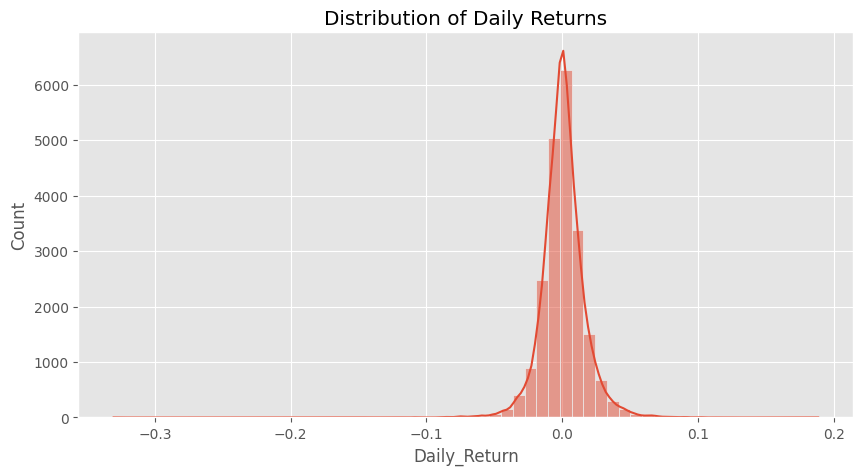

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Daily_Return"],
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [31]:
master_df["Daily_Change"] = (
    master_df["Close"] - master_df["Open"]
)
master_df[
    ["Stock","Date","Open","Close","Daily_Change"]
].head()

,Stock,Date,Open,Close,Daily_Change
0,ADANIPORTS,2023-07-03,729.728331,722.769226,-6.959105
1,ADANIPORTS,2023-07-04,725.366661,726.983948,1.617286
2,ADANIPORTS,2023-07-05,726.297783,728.013062,1.715278
3,ADANIPORTS,2023-07-06,727.670048,725.366638,-2.303409
4,ADANIPORTS,2023-07-07,725.268750,704.440369,-20.828381


In [ ]:
master_df["Daily_Change_%"] = ((master_df["Close"] - master_df["Open"])/ master_df["Open"]) * 100
master_df[
    ["Stock","Date","Open","Close","Daily_Change_%"]
].head()

,Stock,Date,Open,Close,Daily_Change_%
0,ADANIPORTS,2023-07-03,729.728331,722.769226,-0.953657
1,ADANIPORTS,2023-07-04,725.366661,726.983948,0.222961
2,ADANIPORTS,2023-07-05,726.297783,728.013062,0.236167
3,ADANIPORTS,2023-07-06,727.670048,725.366638,-0.316546
4,ADANIPORTS,2023-07-07,725.268750,704.440369,-2.871816


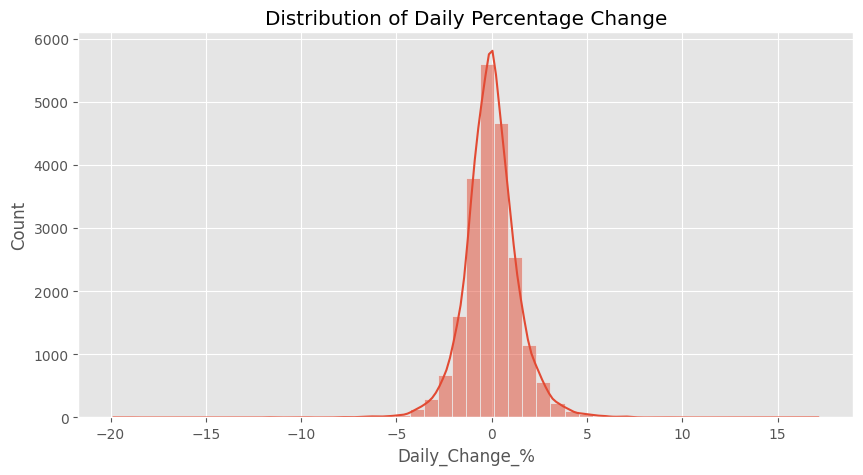

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Daily_Change_%"],
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Percentage Change")

plt.show()

In [34]:
master_df["Price_Range"] = (
    master_df["High"] - master_df["Low"]
)
master_df[
    ["Stock","Date","Open","Close","Price_Range"]
].head()

,Stock,Date,Open,Close,Price_Range
0,ADANIPORTS,2023-07-03,729.728331,722.769226,14.457344
1,ADANIPORTS,2023-07-04,725.366661,726.983948,15.682544
2,ADANIPORTS,2023-07-05,726.297783,728.013062,12.595078
3,ADANIPORTS,2023-07-06,727.670048,725.366638,7.547236
4,ADANIPORTS,2023-07-07,725.268750,704.440369,23.327775


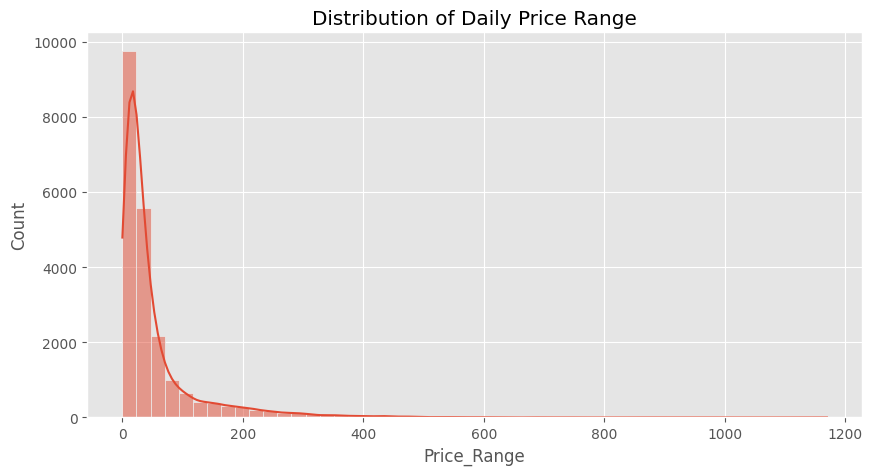

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Price_Range"],
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Price Range")

plt.show()

In [36]:
master_df["Month"] = master_df["Date"].dt.month_name()
master_df["Quarter"] = master_df["Date"].dt.quarter
master_df["Year"] = master_df["Date"].dt.year
master_df[
    ["Date","Month","Quarter","Year"]
].head()

,Date,Month,Quarter,Year
0,2023-07-03,July,3,2023
1,2023-07-04,July,3,2023
2,2023-07-05,July,3,2023
3,2023-07-06,July,3,2023
4,2023-07-07,July,3,2023


In [37]:
master_df["MA20"] = (
    master_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(window=20).mean())
)
master_df[
    ["Stock", "Date", "Close", "MA20"]
].head(25)

,Stock,Date,Close,MA20
0,ADANIPORTS,2023-07-03,722.769226,NaN
1,ADANIPORTS,2023-07-04,726.983948,NaN
2,ADANIPORTS,2023-07-05,728.013062,NaN
3,ADANIPORTS,2023-07-06,725.366638,NaN
4,ADANIPORTS,2023-07-07,704.440369,NaN
5,ADANIPORTS,2023-07-10,705.812500,NaN
6,ADANIPORTS,2023-07-11,715.418091,NaN
7,ADANIPORTS,2023-07-12,709.831116,NaN
8,ADANIPORTS,2023-07-13,702.970032,NaN
9,ADANIPORTS,2023-07-14,711.693420,NaN


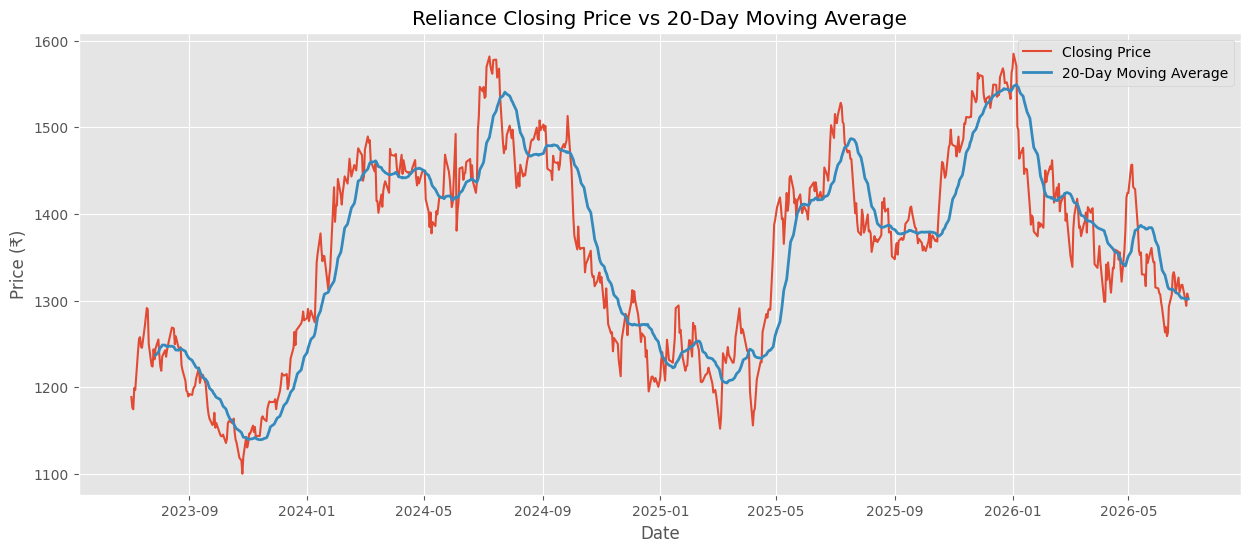

In [38]:
reliance = master_df[
    master_df["Stock"] == "RELIANCE"
]

plt.figure(figsize=(15,6))

plt.plot(
    reliance["Date"],
    reliance["Close"],
    label="Closing Price",
    linewidth=1.5
)

plt.plot(
    reliance["Date"],
    reliance["MA20"],
    label="20-Day Moving Average",
    linewidth=2
)

plt.title("Reliance Closing Price vs 20-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

In [39]:
master_df["MA50"] = (
    master_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(window=50).mean())
)
master_df[
    ["Stock", "Date", "Close", "MA20", "MA50"]
].head(60)

,Stock,Date,Close,MA20,MA50
0,ADANIPORTS,2023-07-03,722.769226,NaN,NaN
1,ADANIPORTS,2023-07-04,726.983948,NaN,NaN
2,ADANIPORTS,2023-07-05,728.013062,NaN,NaN
3,ADANIPORTS,2023-07-06,725.366638,NaN,NaN
4,ADANIPORTS,2023-07-07,704.440369,NaN,NaN
5,ADANIPORTS,2023-07-10,705.812500,NaN,NaN
6,ADANIPORTS,2023-07-11,715.418091,NaN,NaN
7,ADANIPORTS,2023-07-12,709.831116,NaN,NaN
8,ADANIPORTS,2023-07-13,702.970032,NaN,NaN
9,ADANIPORTS,2023-07-14,711.693420,NaN,NaN


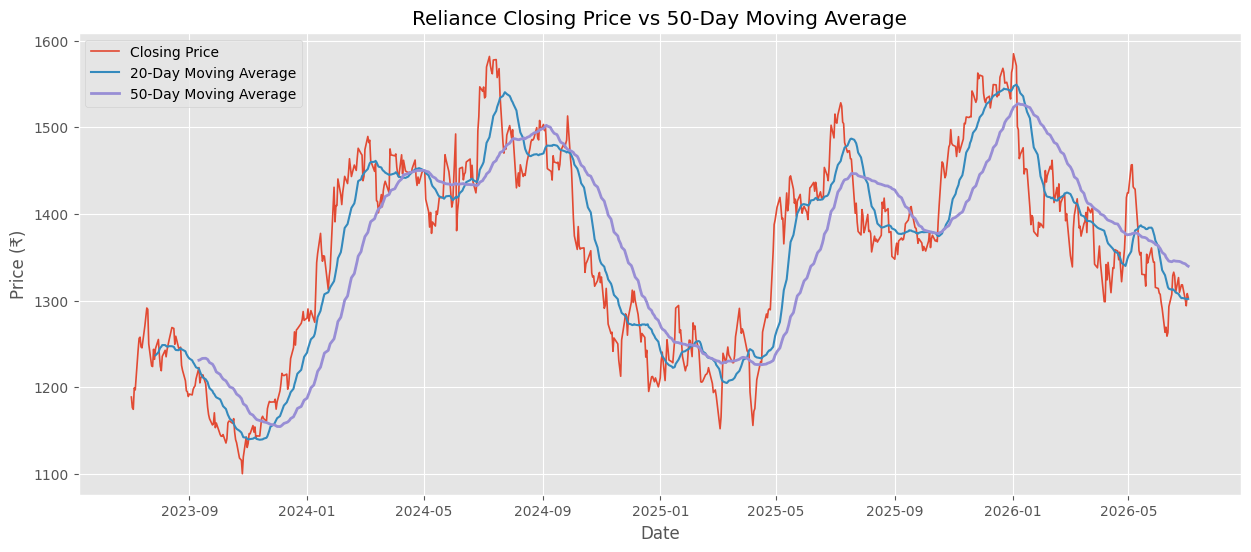

In [40]:
reliance = master_df[
    master_df["Stock"] == "RELIANCE"
]

plt.figure(figsize=(15,6))

plt.plot(
    reliance["Date"],
    reliance["Close"],
    label="Closing Price",
    linewidth=1.2
)

plt.plot(
    reliance["Date"],
    reliance["MA20"],
    label="20-Day Moving Average",
    linewidth=1.5
)

plt.plot(
    reliance["Date"],
    reliance["MA50"],
    label="50-Day Moving Average",
    linewidth=2
)

plt.title("Reliance Closing Price vs 50-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

In [41]:
## Univariate Analysis

In [42]:
master_df["Close"].describe()

count    21547.000000
mean      2497.158778
std       3040.465190
min         73.250000
25%        838.816345
50%       1402.714355
75%       2886.293213
max      17292.000000
Name: Close, dtype: float64

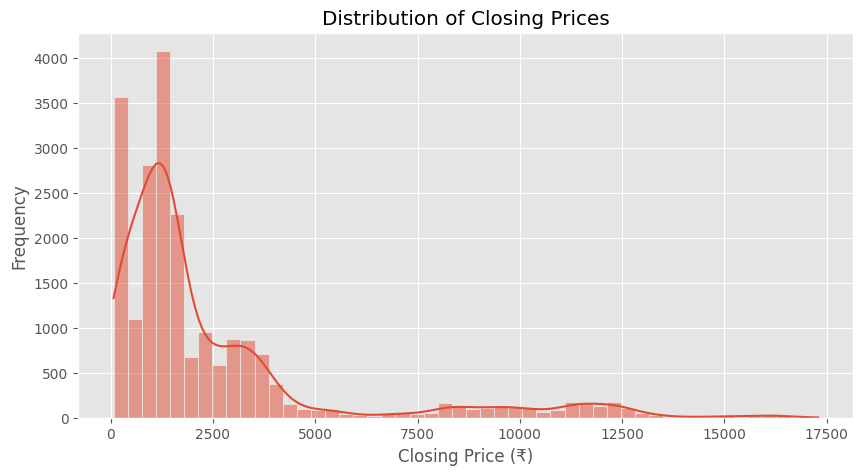

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=master_df,
    x="Close",
    bins=50,
    kde=True
)

plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price (₹)")
plt.ylabel("Frequency")

plt.show()

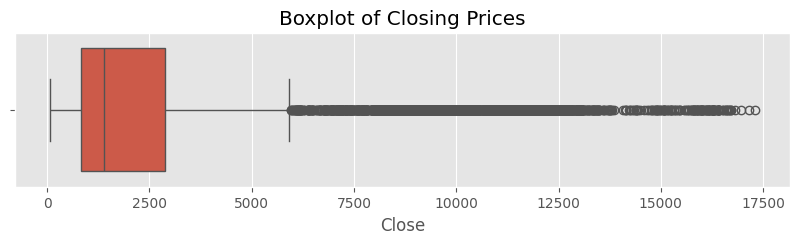

In [44]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=master_df["Close"]
)

plt.title("Boxplot of Closing Prices")

plt.show()

In [45]:
master_df["Open"].describe()

count    21547.000000
mean      2498.144206
std       3041.884336
min         73.449997
25%        837.975737
50%       1403.300130
75%       2891.400382
max      17230.000000
Name: Open, dtype: float64

In [46]:
master_df["High"].describe()

count    21547.000000
mean      2523.100070
std       3071.362740
min         74.900002
25%        848.386731
50%       1416.255364
75%       2923.968373
max      17370.000000
Name: High, dtype: float64

In [47]:
master_df["Low"].describe()

count    21547.000000
mean      2471.398759
std       3009.450017
min         73.000000
25%        829.057689
50%       1389.280225
75%       2855.646947
max      17142.000000
Name: Low, dtype: float64

In [48]:
master_df["Volume"].describe()

count    2.154700e+04
mean     9.726690e+06
std      1.776839e+07
min      0.000000e+00
25%      1.314832e+06
50%      3.557067e+06
75%      1.160395e+07
max      4.675740e+08
Name: Volume, dtype: float64

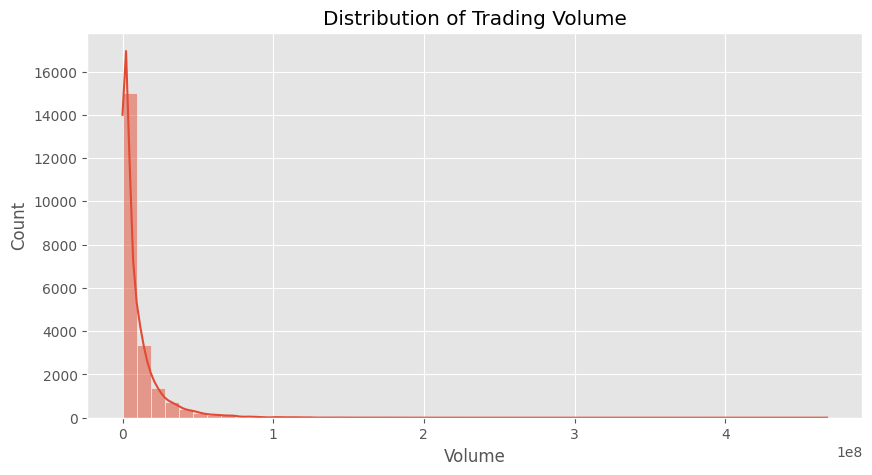

In [49]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=master_df,
    x="Volume",
    bins=50,
    kde=True
)

plt.title("Distribution of Trading Volume")

plt.show()

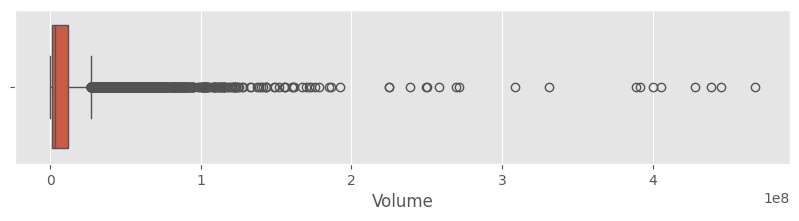

In [50]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=master_df["Volume"]
)

plt.show()

In [51]:
master_df["Daily_Return"].describe()

count    21518.000000
mean         0.000627
std          0.016231
min         -0.330467
25%         -0.007700
50%          0.000192
75%          0.008421
max          0.188633
Name: Daily_Return, dtype: float64

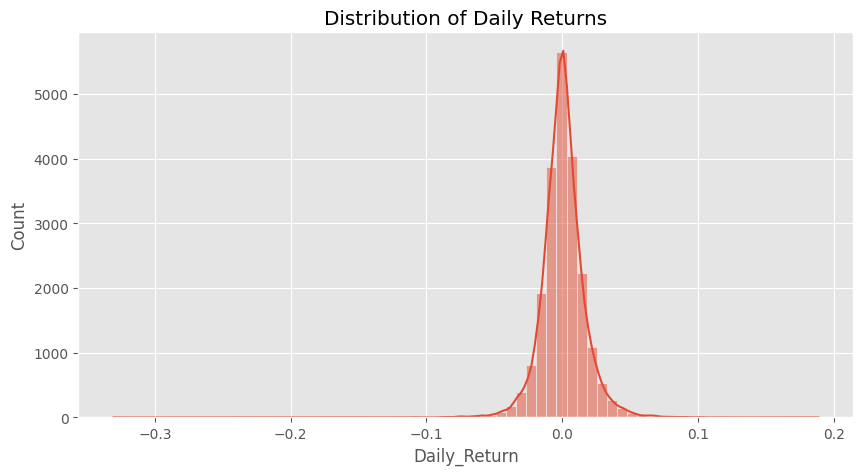

In [52]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Daily_Return"],
    bins=70,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

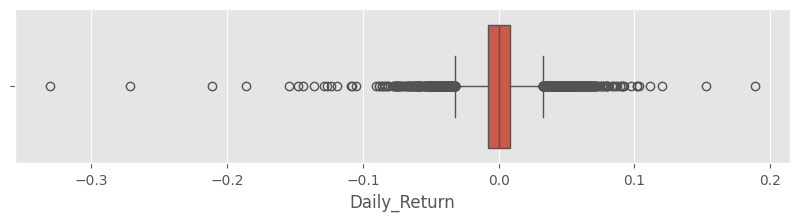

In [53]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=master_df["Daily_Return"]
)

plt.show()

In [54]:
master_df["Price_Range"].describe()

count    21547.000000
mean        51.701311
std         75.156728
min          0.000000
25%         12.912646
50%         26.029628
75%         53.600958
max       1169.821141
Name: Price_Range, dtype: float64

In [55]:
master_df["Daily_Change_%"].describe()

count    21547.000000
mean        -0.023021
std          1.431595
min        -19.836332
25%         -0.808255
50%         -0.039435
75%          0.730345
max         17.126623
Name: Daily_Change_%, dtype: float64

In [56]:
master_df["Stock"].value_counts()

Stock
ADANIPORTS    743
ASIANPAINT    743
AXISBANK      743
BAJAJ-AUTO    743
BAJFINANCE    743
BHARTIARTL    743
ETERNAL       743
HCLTECH       743
HDFCBANK      743
HINDUNILVR    743
ICICIBANK     743
INDUSINDBK    743
INFY          743
KOTAKBANK     743
LT            743
M&M           743
MARUTI        743
NESTLEIND     743
NTPC          743
POWERGRID     743
RELIANCE      743
SBIN          743
SUNPHARMA     743
TATASTEEL     743
TCS           743
TECHM         743
TITAN         743
TRENT         743
ULTRACEMCO    743
Name: count, dtype: int64

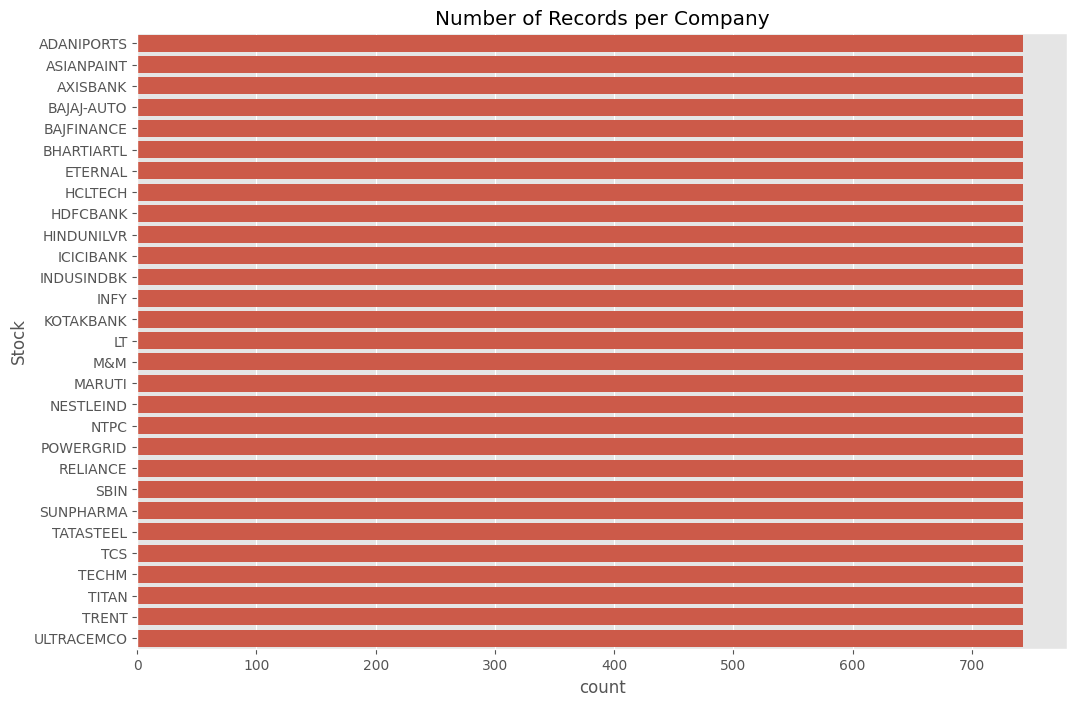

In [57]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=master_df,
    y="Stock",
    order=master_df["Stock"].value_counts().index
)

plt.title("Number of Records per Company")

plt.show()

In [58]:
## Bivariate Analysis

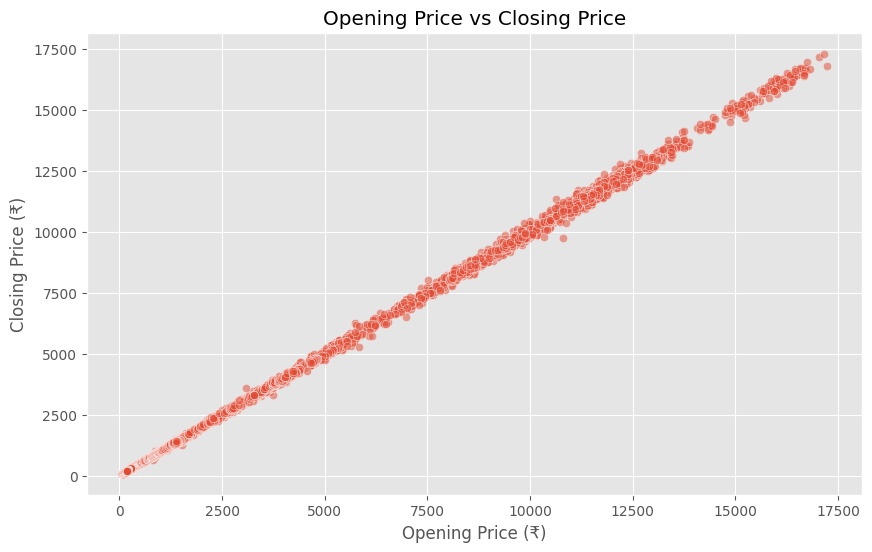

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master_df,
    x="Open",
    y="Close",
    alpha=0.5
)

plt.title("Opening Price vs Closing Price")
plt.xlabel("Opening Price (₹)")
plt.ylabel("Closing Price (₹)")

plt.show()

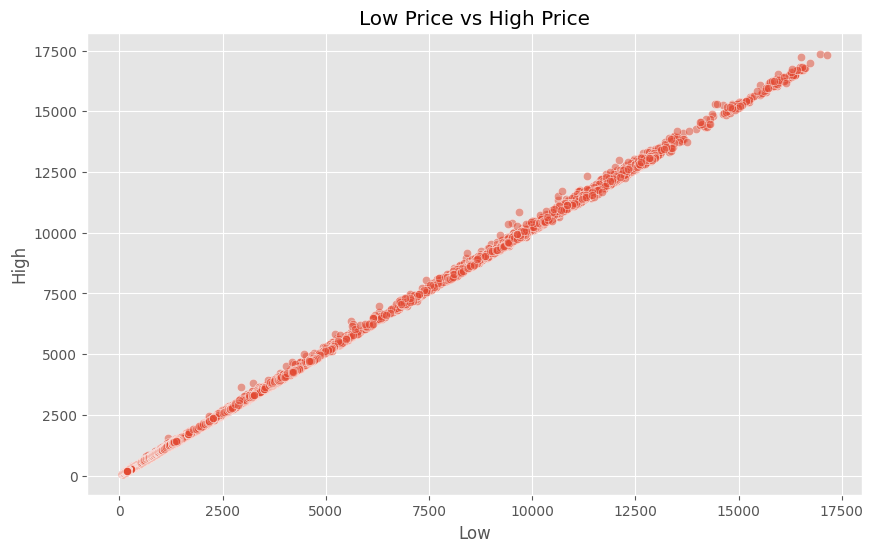

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master_df,
    x="Low",
    y="High",
    alpha=0.5
)

plt.title("Low Price vs High Price")

plt.show()

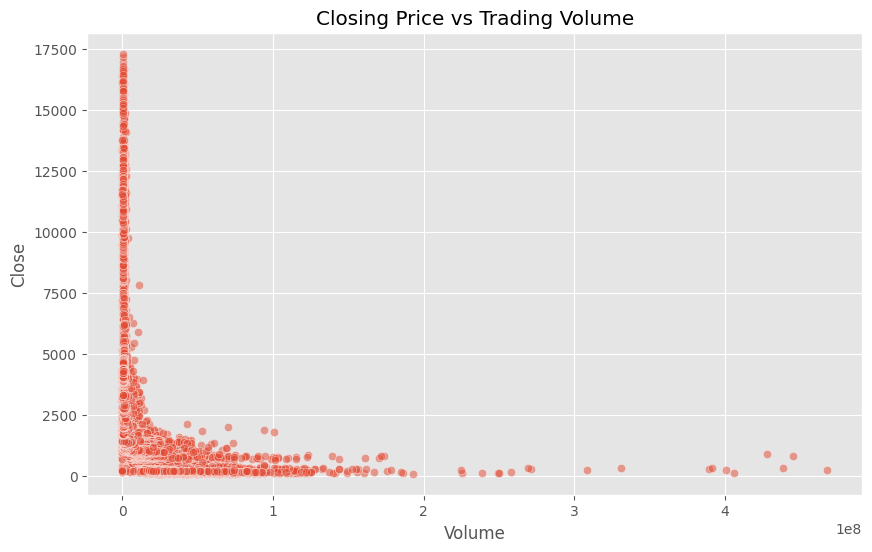

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master_df,
    x="Volume",
    y="Close",
    alpha=0.5
)

plt.title("Closing Price vs Trading Volume")

plt.show()

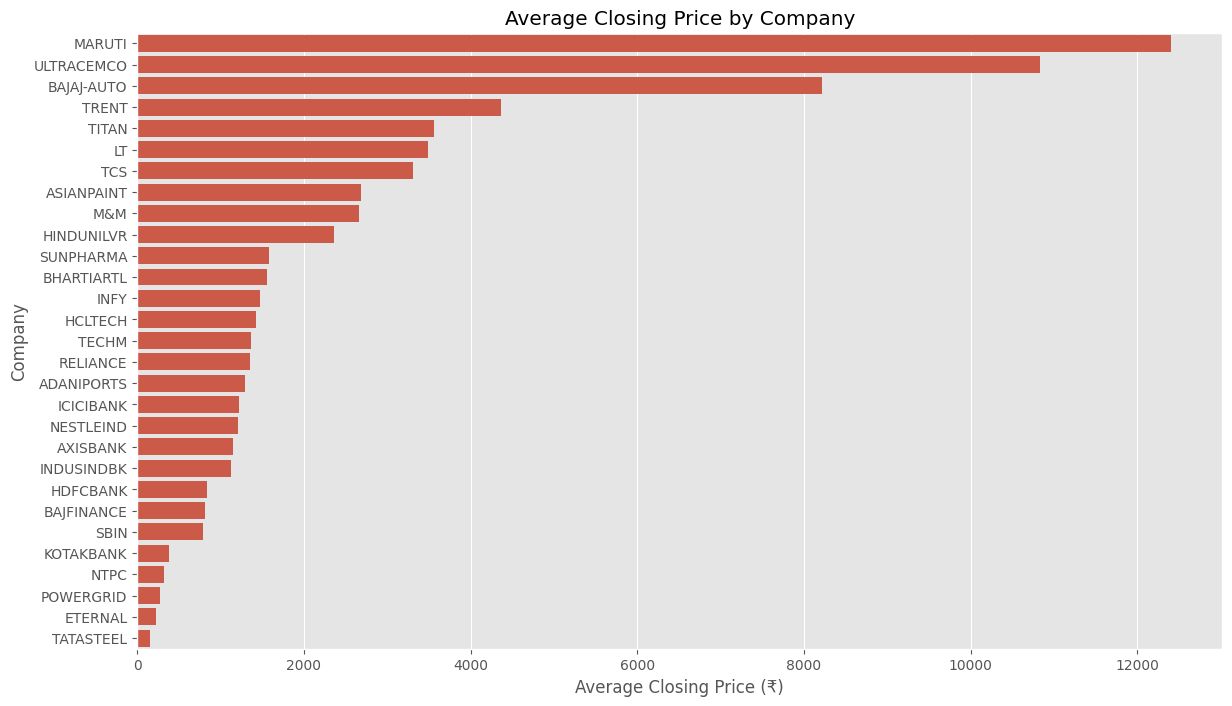

In [62]:
avg_close = (
    master_df.groupby("Stock")["Close"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=avg_close.values,
    y=avg_close.index
)

plt.title("Average Closing Price by Company")
plt.xlabel("Average Closing Price (₹)")
plt.ylabel("Company")

plt.show()

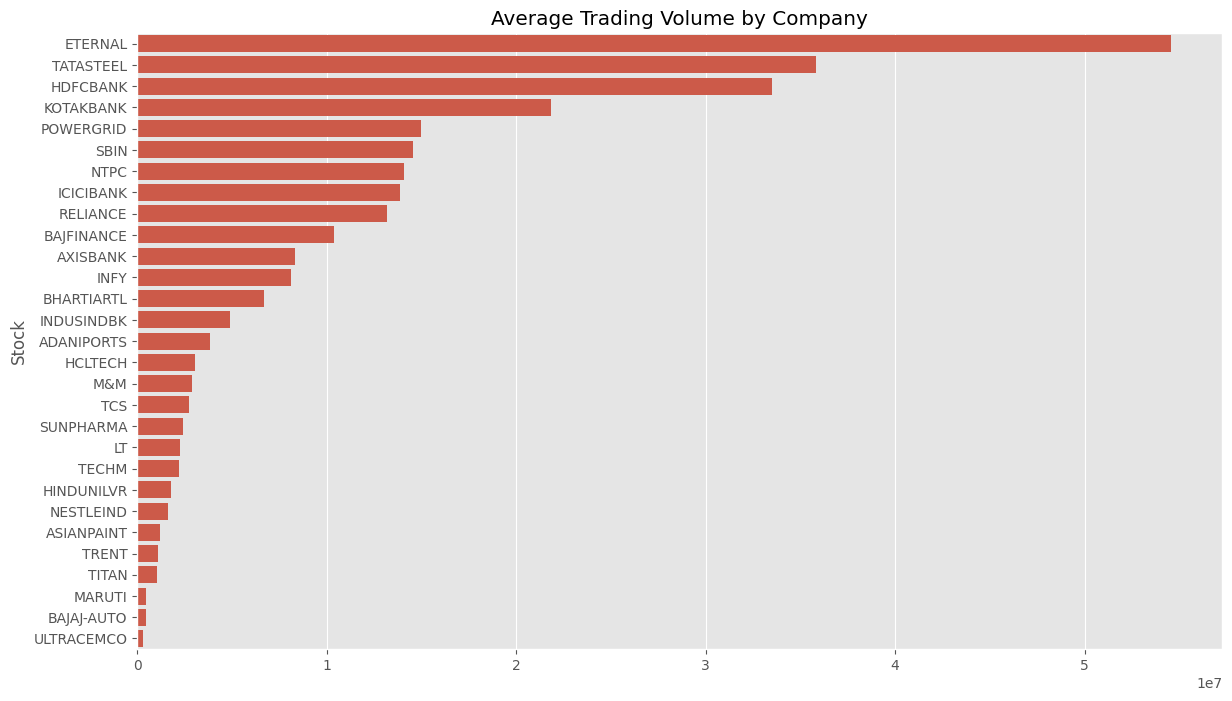

In [63]:
avg_volume = (
    master_df.groupby("Stock")["Volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=avg_volume.values,
    y=avg_volume.index
)

plt.title("Average Trading Volume by Company")

plt.show()

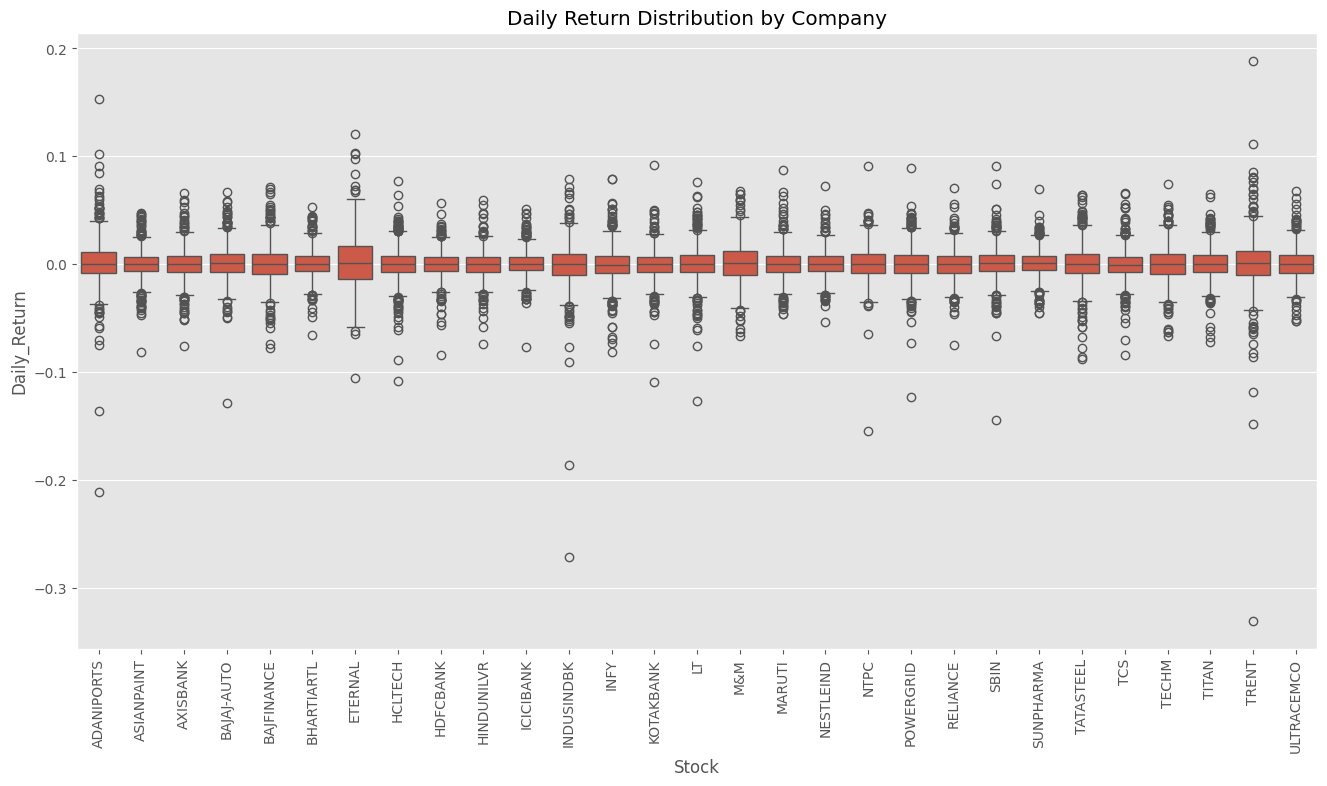

In [64]:
plt.figure(figsize=(16,8))

sns.boxplot(
    data=master_df,
    x="Stock",
    y="Daily_Return"
)

plt.xticks(rotation=90)

plt.title("Daily Return Distribution by Company")

plt.show()

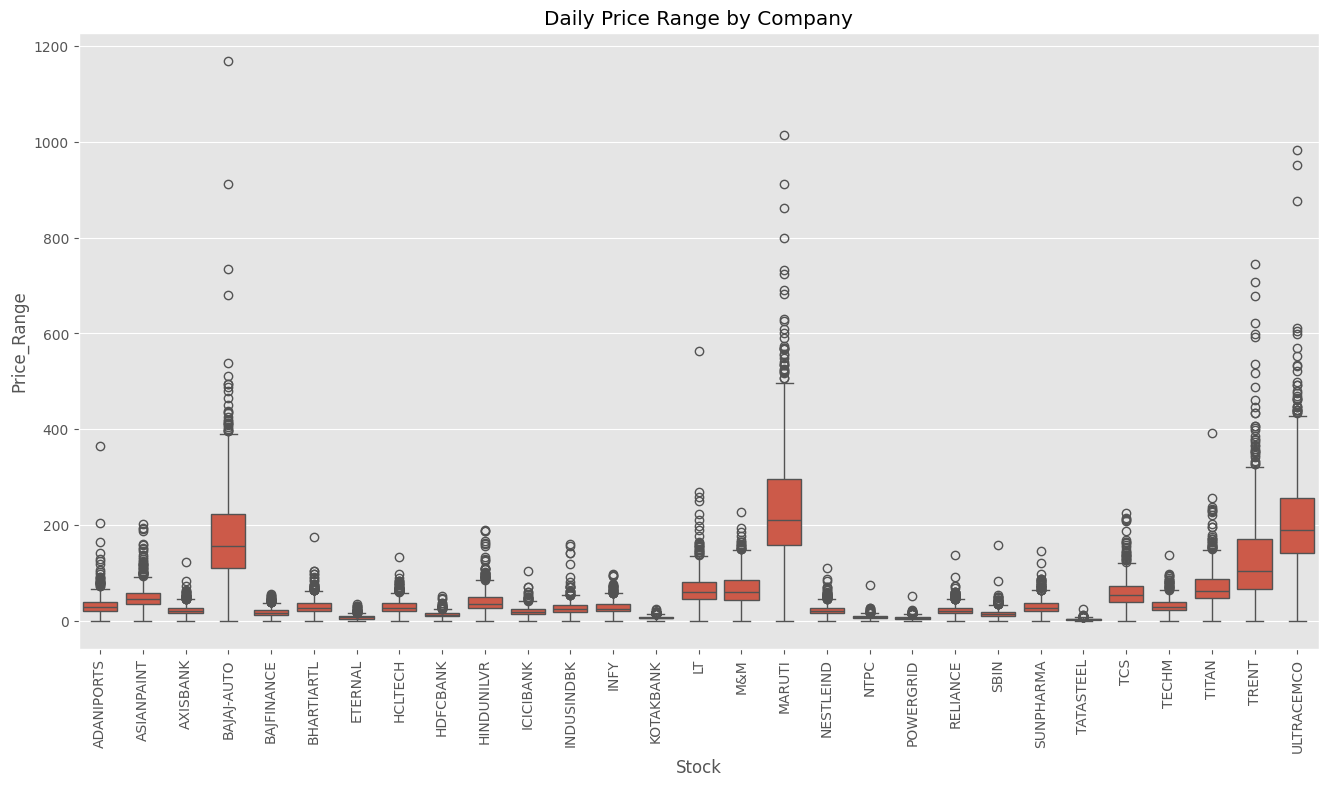

In [65]:
plt.figure(figsize=(16,8))

sns.boxplot(
    data=master_df,
    x="Stock",
    y="Price_Range"
)

plt.xticks(rotation=90)

plt.title("Daily Price Range by Company")

plt.show()

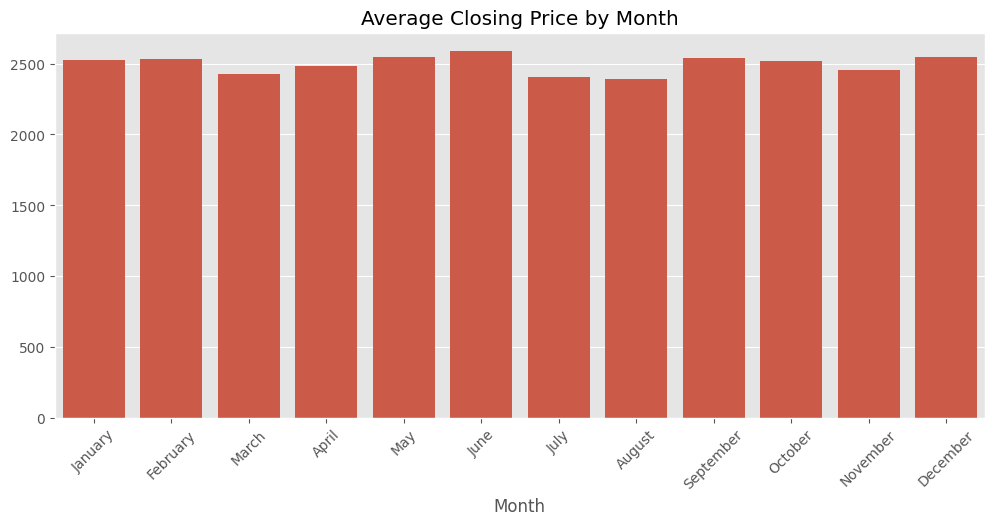

In [66]:
monthly_close = (
    master_df.groupby("Month")["Close"]
    .mean()
    .reindex([
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ])
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_close.index,
    y=monthly_close.values
)

plt.xticks(rotation=45)

plt.title("Average Closing Price by Month")

plt.show()

In [67]:
## Multivariate Analysis

In [68]:
close_prices = master_df.pivot(
    index="Date",
    columns="Stock",
    values="Close"
)

correlation = close_prices.corr()

correlation.head()

Stock,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BHARTIARTL,ETERNAL,HCLTECH,HDFCBANK,HINDUNILVR,...,POWERGRID,RELIANCE,SBIN,SUNPHARMA,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO
Stock,,,,,,,,,,,,,,,,,,,,,
ADANIPORTS,1.000000,-0.351908,0.838650,0.883071,0.458639,0.757349,0.738453,0.321294,0.297068,-0.085142,...,0.809191,0.696262,0.836778,0.801826,0.863348,-0.257642,0.555966,0.707491,0.310415,0.767132
ASIANPAINT,-0.351908,1.000000,-0.230357,-0.345202,-0.473124,-0.659553,-0.575724,-0.419691,-0.444682,0.488444,...,-0.495884,-0.040473,-0.487761,-0.590619,-0.396541,0.224649,-0.552900,-0.191729,-0.281522,-0.598183
AXISBANK,0.838650,-0.230357,1.000000,0.731206,0.525443,0.685779,0.592931,0.231568,0.332625,-0.064602,...,0.647383,0.592624,0.871044,0.625203,0.851349,-0.354685,0.474124,0.762467,0.093627,0.678107
BAJAJ-AUTO,0.883071,-0.345202,0.731206,1.000000,0.272821,0.726641,0.784749,0.550074,0.256685,0.086836,...,0.900945,0.615705,0.756316,0.886727,0.731243,0.027163,0.687115,0.586380,0.554952,0.778818
BAJFINANCE,0.458639,-0.473124,0.525443,0.272821,1.000000,0.770836,0.590076,0.048951,0.710025,-0.155447,...,0.167037,0.258131,0.624083,0.388490,0.606059,-0.683073,0.359044,0.527673,-0.143866,0.612130


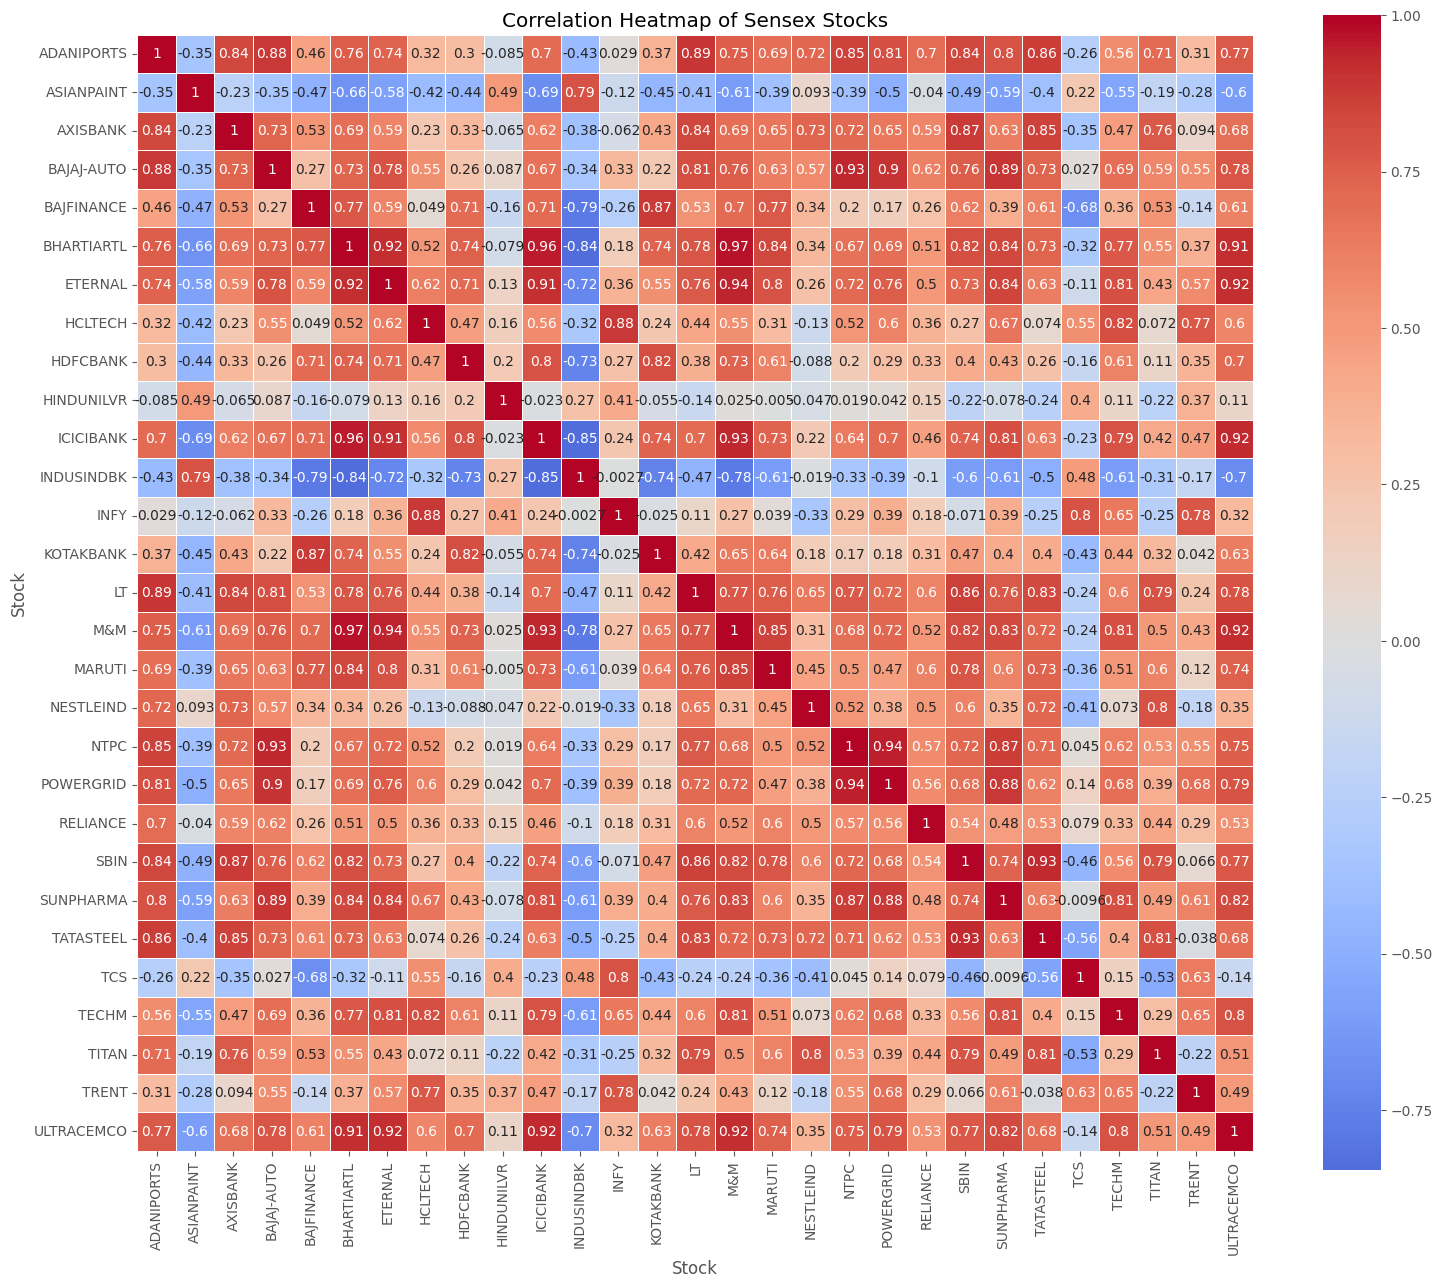

In [97]:
plt.figure(figsize=(18,15))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True, annot=True
)

plt.title("Correlation Heatmap of Sensex Stocks")

plt.show()

In [70]:
risk_return = master_df.groupby("Stock").agg(
    Avg_Return=("Daily_Return", "mean"),
    Risk=("Daily_Return", "std")
).reset_index()

risk_return.head()

,Stock,Avg_Return,Risk
0,ADANIPORTS,0.001514,0.021426
1,ASIANPAINT,-0.000146,0.013349
2,AXISBANK,0.000552,0.014669
3,BAJAJ-AUTO,0.001199,0.015936
4,BAJFINANCE,0.000615,0.016924


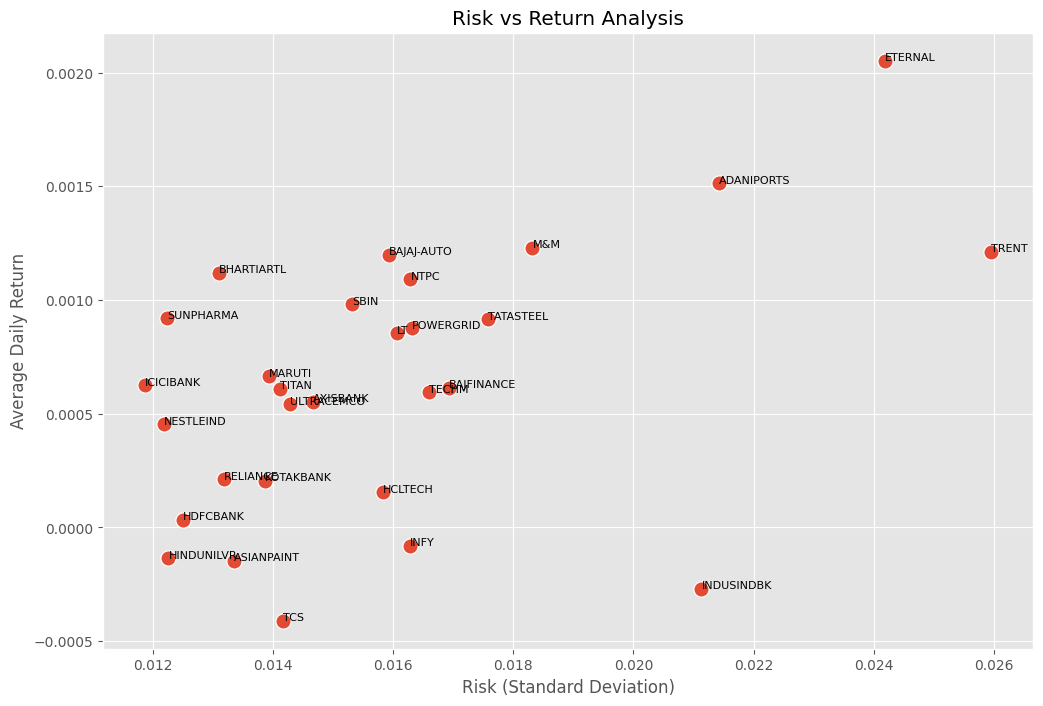

In [71]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=risk_return,
    x="Risk",
    y="Avg_Return",
    s=120
)

for i in range(len(risk_return)):
    plt.text(
        risk_return["Risk"][i],
        risk_return["Avg_Return"][i],
        risk_return["Stock"][i],
        fontsize=8
    )

plt.title("Risk vs Return Analysis")

plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Average Daily Return")

plt.show()

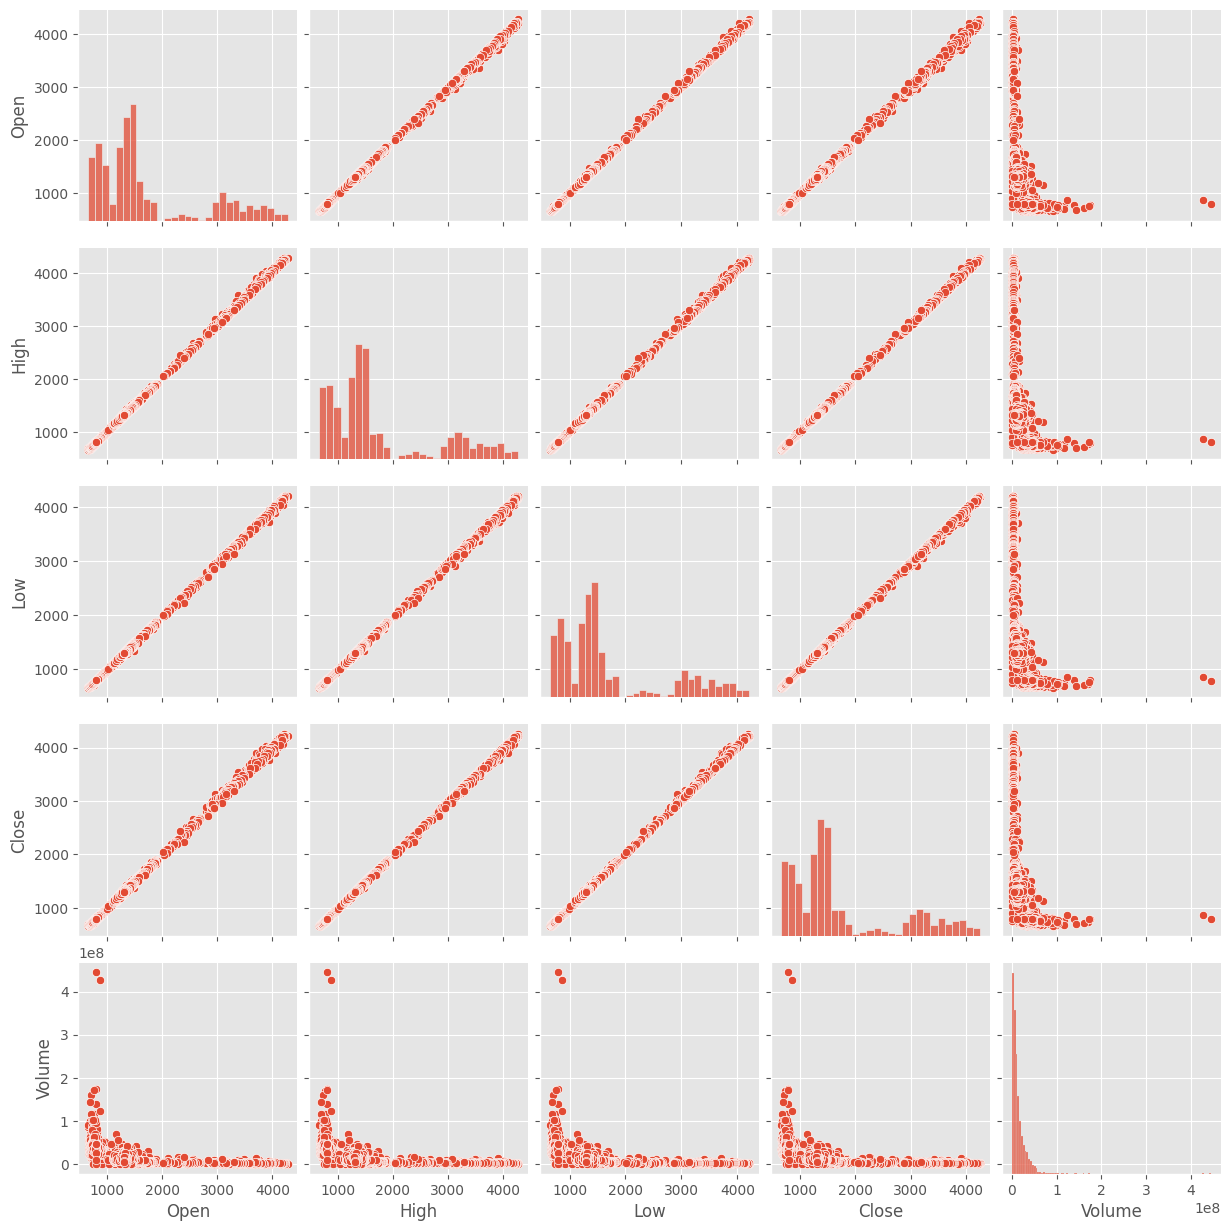

In [72]:
selected = master_df[
    master_df["Stock"].isin(
        ["RELIANCE","TCS","INFY","HDFCBANK"]
    )
]
sns.pairplot(
    selected[
        [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]
)

plt.show()

In [73]:
correlation.round(2)

Stock,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BHARTIARTL,ETERNAL,HCLTECH,HDFCBANK,HINDUNILVR,...,POWERGRID,RELIANCE,SBIN,SUNPHARMA,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO
Stock,,,,,,,,,,,,,,,,,,,,,
ADANIPORTS,1.00,-0.35,0.84,0.88,0.46,0.76,0.74,0.32,0.30,-0.09,...,0.81,0.70,0.84,0.80,0.86,-0.26,0.56,0.71,0.31,0.77
ASIANPAINT,-0.35,1.00,-0.23,-0.35,-0.47,-0.66,-0.58,-0.42,-0.44,0.49,...,-0.50,-0.04,-0.49,-0.59,-0.40,0.22,-0.55,-0.19,-0.28,-0.60
AXISBANK,0.84,-0.23,1.00,0.73,0.53,0.69,0.59,0.23,0.33,-0.06,...,0.65,0.59,0.87,0.63,0.85,-0.35,0.47,0.76,0.09,0.68
BAJAJ-AUTO,0.88,-0.35,0.73,1.00,0.27,0.73,0.78,0.55,0.26,0.09,...,0.90,0.62,0.76,0.89,0.73,0.03,0.69,0.59,0.55,0.78
BAJFINANCE,0.46,-0.47,0.53,0.27,1.00,0.77,0.59,0.05,0.71,-0.16,...,0.17,0.26,0.62,0.39,0.61,-0.68,0.36,0.53,-0.14,0.61
BHARTIARTL,0.76,-0.66,0.69,0.73,0.77,1.00,0.92,0.52,0.74,-0.08,...,0.69,0.51,0.82,0.84,0.73,-0.32,0.77,0.55,0.37,0.91
ETERNAL,0.74,-0.58,0.59,0.78,0.59,0.92,1.00,0.62,0.71,0.13,...,0.76,0.50,0.73,0.84,0.63,-0.11,0.81,0.43,0.57,0.92
HCLTECH,0.32,-0.42,0.23,0.55,0.05,0.52,0.62,1.00,0.47,0.16,...,0.60,0.36,0.27,0.67,0.07,0.55,0.82,0.07,0.77,0.60
HDFCBANK,0.30,-0.44,0.33,0.26,0.71,0.74,0.71,0.47,1.00,0.20,...,0.29,0.33,0.40,0.43,0.26,-0.16,0.61,0.11,0.35,0.70


In [74]:
corr_pairs = (
    correlation.where(
        np.triu(np.ones(correlation.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10)

Stock       Stock     
BHARTIARTL  M&M           0.965997
            ICICIBANK     0.956542
NTPC        POWERGRID     0.944832
ETERNAL     M&M           0.938525
BAJAJ-AUTO  NTPC          0.934676
ICICIBANK   M&M           0.930074
SBIN        TATASTEEL     0.927287
ICICIBANK   ULTRACEMCO    0.921794
M&M         ULTRACEMCO    0.920653
BHARTIARTL  ETERNAL       0.915499
dtype: float64

In [75]:
## Time Series Analysis

In [76]:
stock_df = master_df[
    master_df["Stock"] == "RELIANCE"
].copy()

stock_df.sort_values("Date", inplace=True)

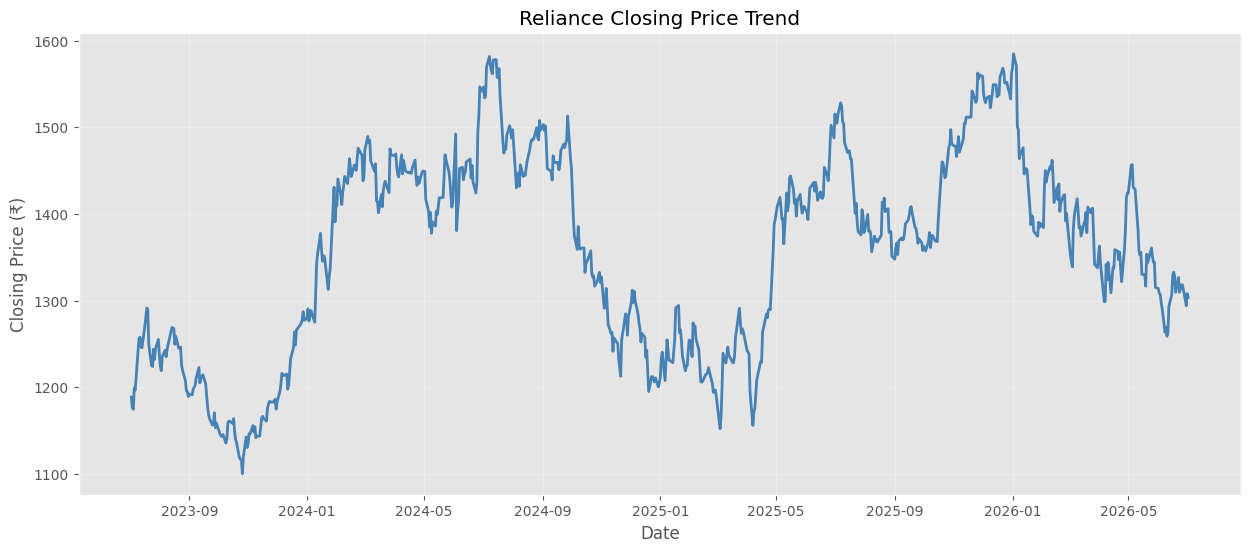

In [77]:
plt.figure(figsize=(15,6))

plt.plot(
    stock_df["Date"],
    stock_df["Close"],
    linewidth=2,
    color="steelblue"
)

plt.title("Reliance Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")

plt.grid(alpha=0.3)

plt.show()

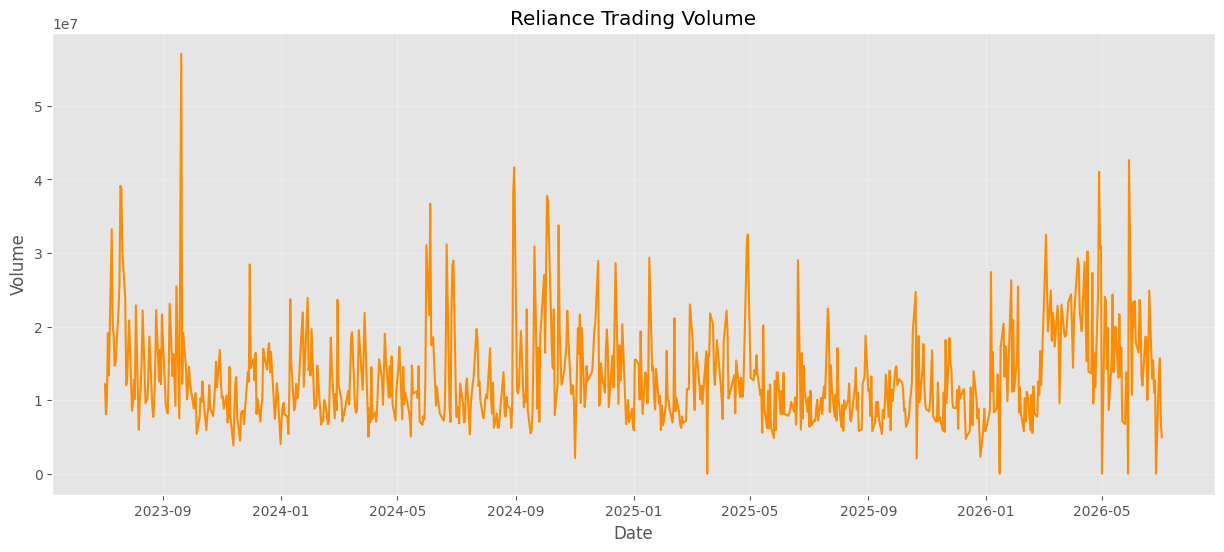

In [78]:
plt.figure(figsize=(15,6))

plt.plot(
    stock_df["Date"],
    stock_df["Volume"],
    color="darkorange"
)

plt.title("Reliance Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(alpha=0.3)

plt.show()

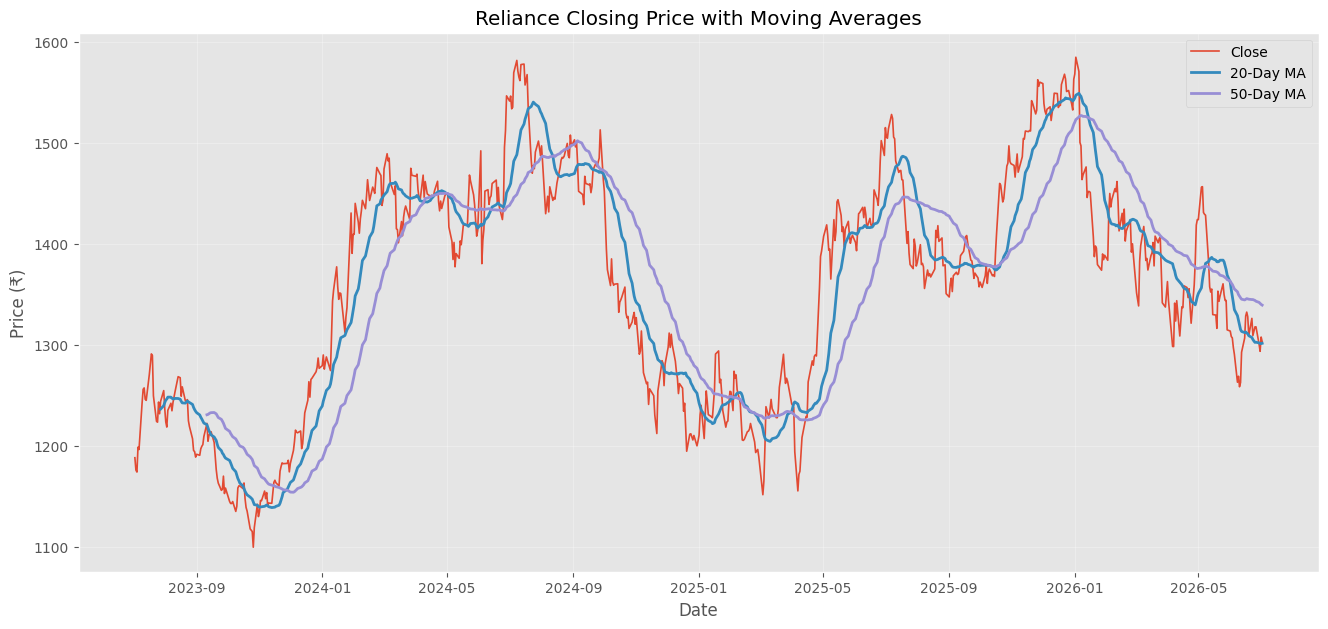

In [79]:
plt.figure(figsize=(16,7))

plt.plot(
    stock_df["Date"],
    stock_df["Close"],
    label="Close",
    linewidth=1.2
)

plt.plot(
    stock_df["Date"],
    stock_df["MA20"],
    label="20-Day MA",
    linewidth=2
)

plt.plot(
    stock_df["Date"],
    stock_df["MA50"],
    label="50-Day MA",
    linewidth=2
)

plt.title("Reliance Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

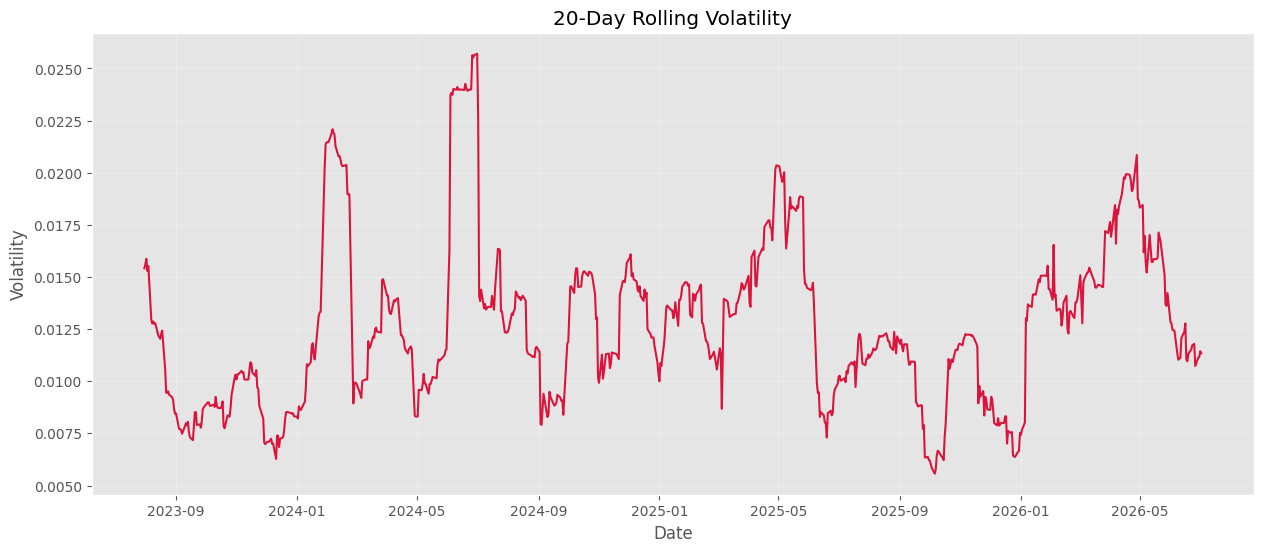

In [80]:
stock_df["Rolling_Volatility"] = (
    stock_df["Daily_Return"]
    .rolling(window=20)
    .std()
)
plt.figure(figsize=(15,6))

plt.plot(
    stock_df["Date"],
    stock_df["Rolling_Volatility"],
    color="crimson"
)

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)

plt.show()

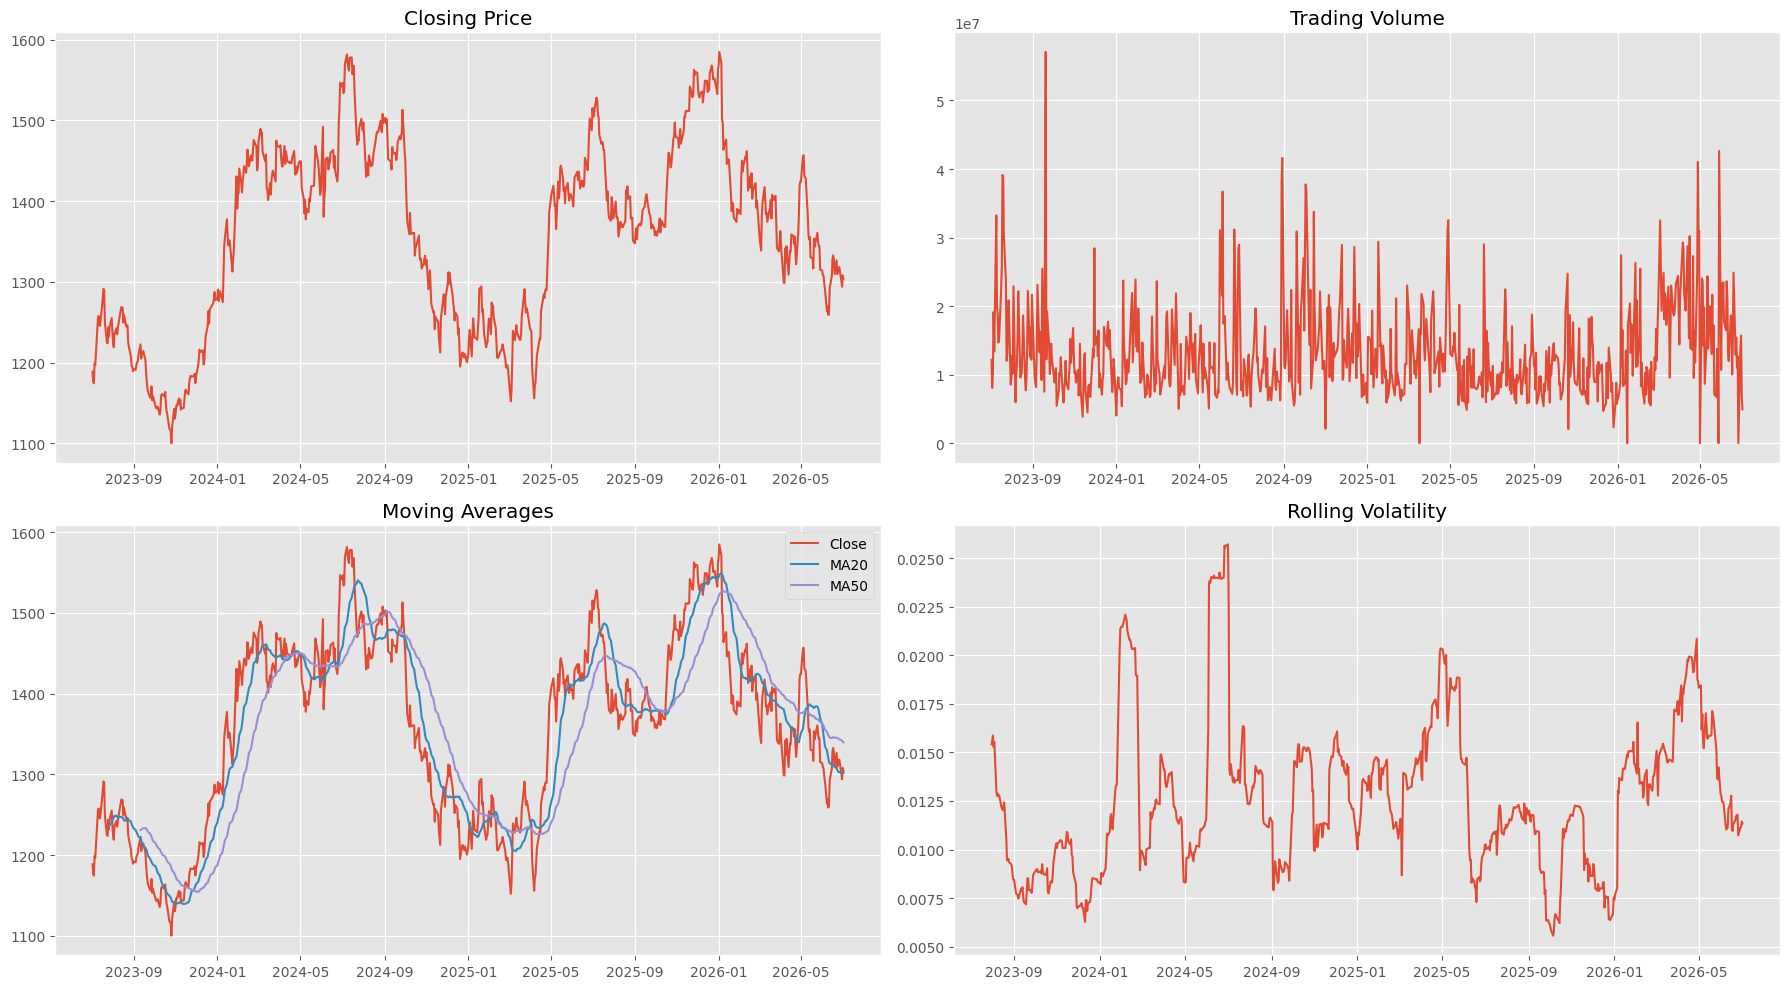

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(18,10))

# Price
axes[0,0].plot(stock_df["Date"], stock_df["Close"])
axes[0,0].set_title("Closing Price")

# Volume
axes[0,1].plot(stock_df["Date"], stock_df["Volume"])
axes[0,1].set_title("Trading Volume")

# Moving Average
axes[1,0].plot(stock_df["Date"], stock_df["Close"], label="Close")
axes[1,0].plot(stock_df["Date"], stock_df["MA20"], label="MA20")
axes[1,0].plot(stock_df["Date"], stock_df["MA50"], label="MA50")
axes[1,0].legend()
axes[1,0].set_title("Moving Averages")

# Volatility
axes[1,1].plot(stock_df["Date"], stock_df["Rolling_Volatility"])
axes[1,1].set_title("Rolling Volatility")

plt.tight_layout()
plt.show()

In [82]:
## Financial Performance & Risk Analysis

In [83]:
avg_return = (
    master_df.groupby("Stock")["Daily_Return"]
    .mean()
    .sort_values(ascending=False)
)

avg_return

Stock
ETERNAL       0.002053
ADANIPORTS    0.001514
M&M           0.001230
TRENT         0.001213
BAJAJ-AUTO    0.001199
BHARTIARTL    0.001120
NTPC          0.001092
SBIN          0.000982
SUNPHARMA     0.000920
TATASTEEL     0.000916
POWERGRID     0.000877
LT            0.000854
MARUTI        0.000666
ICICIBANK     0.000626
BAJFINANCE    0.000615
TITAN         0.000611
TECHM         0.000596
AXISBANK      0.000552
ULTRACEMCO    0.000541
NESTLEIND     0.000455
RELIANCE      0.000211
KOTAKBANK     0.000205
HCLTECH       0.000156
HDFCBANK      0.000035
INFY         -0.000080
HINDUNILVR   -0.000136
ASIANPAINT   -0.000146
INDUSINDBK   -0.000269
TCS          -0.000410
Name: Daily_Return, dtype: float64

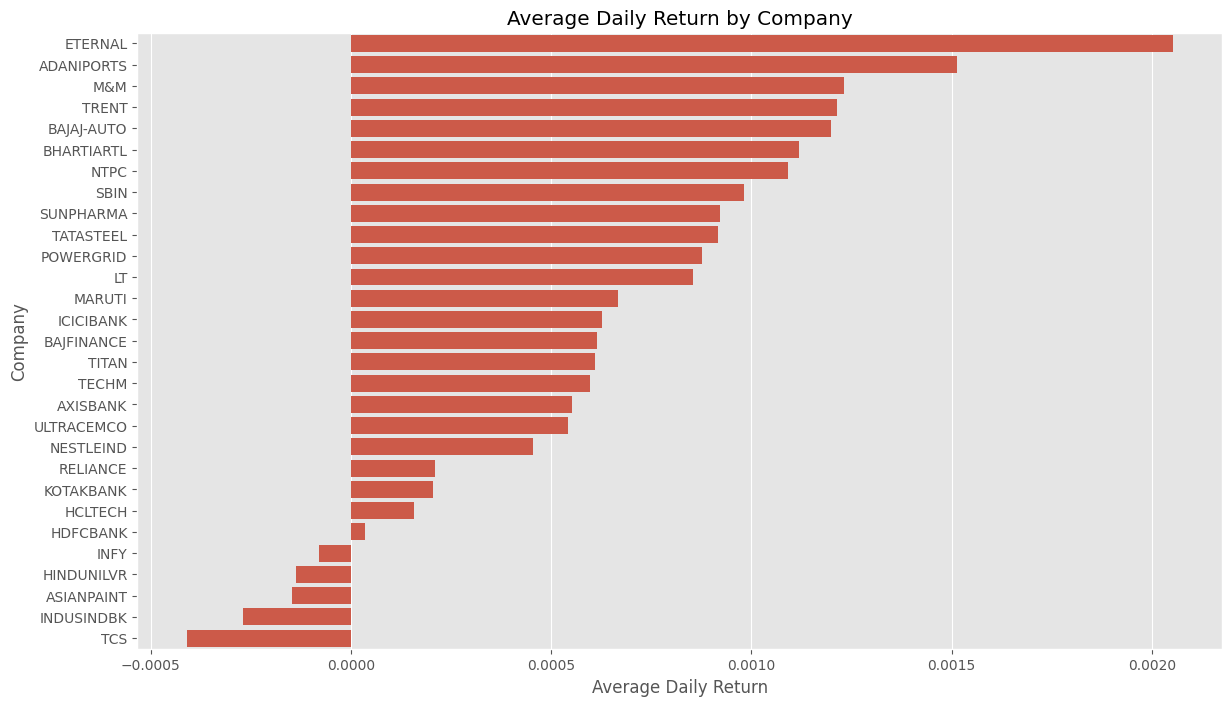

In [84]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=avg_return.values,
    y=avg_return.index
)

plt.title("Average Daily Return by Company")
plt.xlabel("Average Daily Return")
plt.ylabel("Company")

plt.show()

In [85]:
performance = master_df.groupby("Stock").agg(
    First_Close=("Close","first"),
    Last_Close=("Close","last")
)

performance["Total_Return_%"] = (
    (performance["Last_Close"]-performance["First_Close"])
    /performance["First_Close"]
)*100

performance.sort_values(
    "Total_Return_%",
    ascending=False,
    inplace=True
)

performance

,First_Close,Last_Close,Total_Return_%
Stock,,,
ETERNAL,75.650002,279.500000,269.464632
ADANIPORTS,722.769226,1869.500000,158.657941
BAJAJ-AUTO,4398.532715,9738.000000,121.392010
M&M,1415.588745,3113.500000,119.943823
BHARTIARTL,863.065063,1858.099976,115.290834
NTPC,176.362061,359.000000,103.558520
SBIN,554.465759,1052.099976,89.750216
TRENT,1747.157349,3296.600098,88.683641
SUNPHARMA,1004.034119,1879.900024,87.234676


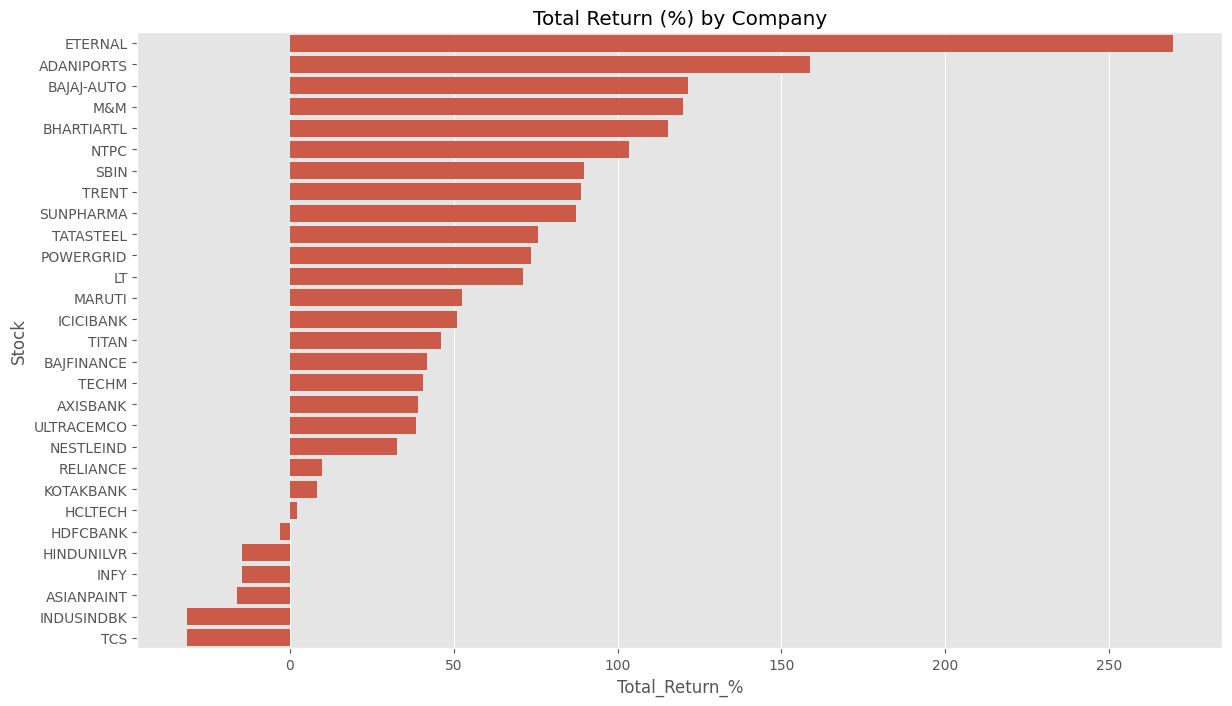

In [86]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=performance["Total_Return_%"],
    y=performance.index
)

plt.title("Total Return (%) by Company")

plt.show()

In [87]:
volatility = (
    master_df.groupby("Stock")["Daily_Return"]
    .std()
    .sort_values(ascending=False)
)

volatility

Stock
TRENT         0.025949
ETERNAL       0.024191
ADANIPORTS    0.021426
INDUSINDBK    0.021134
M&M           0.018319
TATASTEEL     0.017587
BAJFINANCE    0.016924
TECHM         0.016598
POWERGRID     0.016312
NTPC          0.016289
INFY          0.016281
LT            0.016066
BAJAJ-AUTO    0.015936
HCLTECH       0.015837
SBIN          0.015313
AXISBANK      0.014669
ULTRACEMCO    0.014282
TCS           0.014161
TITAN         0.014125
MARUTI        0.013938
KOTAKBANK     0.013868
ASIANPAINT    0.013349
RELIANCE      0.013183
BHARTIARTL    0.013097
HDFCBANK      0.012508
HINDUNILVR    0.012259
SUNPHARMA     0.012242
NESTLEIND     0.012189
ICICIBANK     0.011875
Name: Daily_Return, dtype: float64

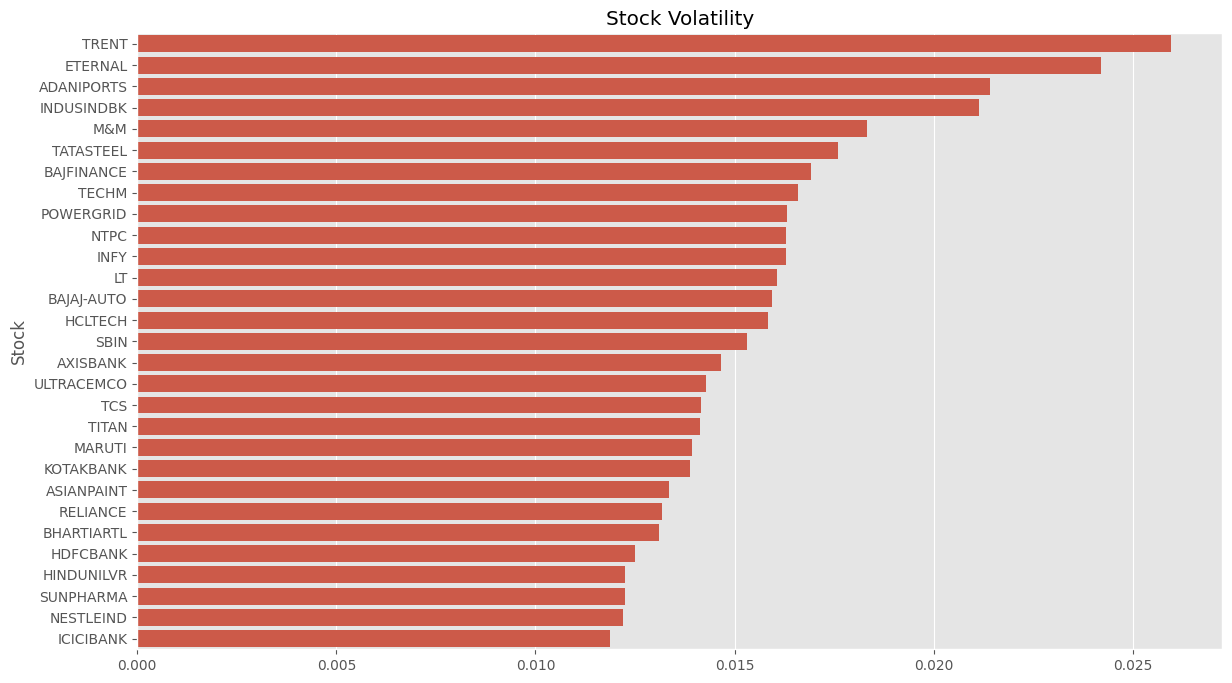

In [88]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=volatility.values,
    y=volatility.index
)

plt.title("Stock Volatility")

plt.show()

In [89]:
performance.head(10)

,First_Close,Last_Close,Total_Return_%
Stock,,,
ETERNAL,75.650002,279.500000,269.464632
ADANIPORTS,722.769226,1869.500000,158.657941
BAJAJ-AUTO,4398.532715,9738.000000,121.392010
M&M,1415.588745,3113.500000,119.943823
BHARTIARTL,863.065063,1858.099976,115.290834
NTPC,176.362061,359.000000,103.558520
SBIN,554.465759,1052.099976,89.750216
TRENT,1747.157349,3296.600098,88.683641
SUNPHARMA,1004.034119,1879.900024,87.234676


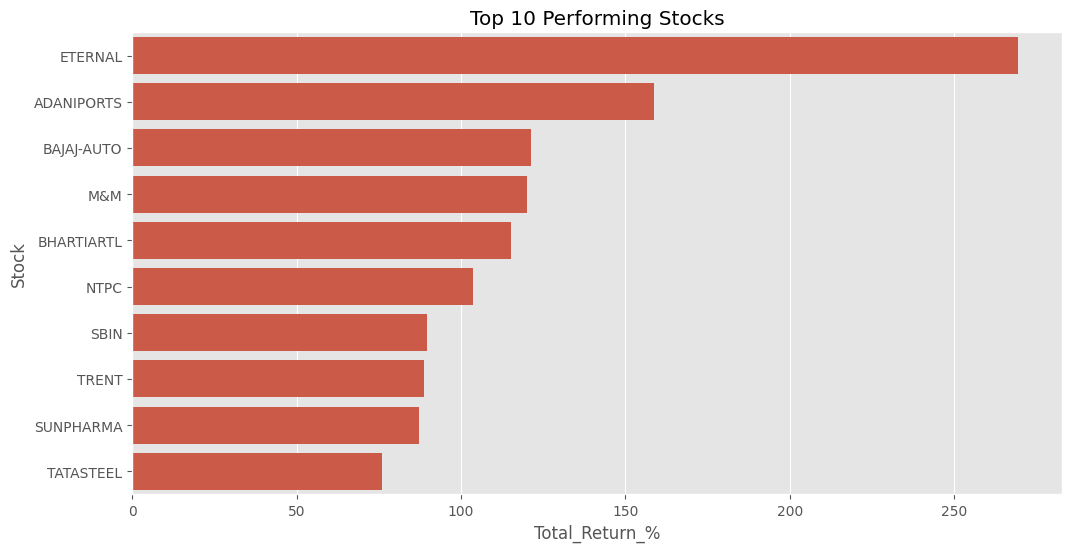

In [90]:
top10 = performance.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10["Total_Return_%"],
    y=top10.index
)

plt.title("Top 10 Performing Stocks")

plt.show()

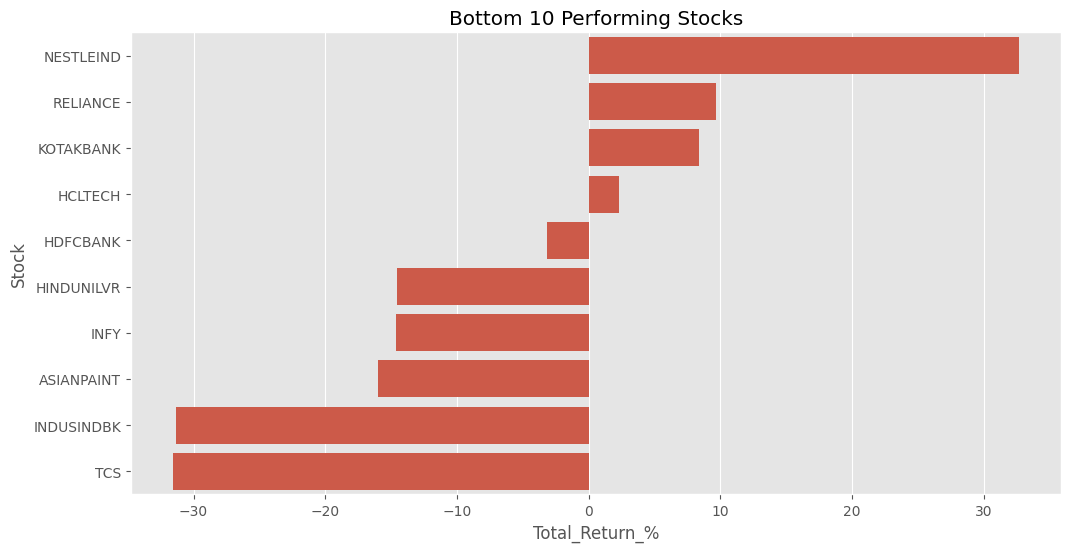

In [91]:
bottom10 = performance.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=bottom10["Total_Return_%"],
    y=bottom10.index
)

plt.title("Bottom 10 Performing Stocks")

plt.show()

In [92]:
volatility.head(10)

Stock
TRENT         0.025949
ETERNAL       0.024191
ADANIPORTS    0.021426
INDUSINDBK    0.021134
M&M           0.018319
TATASTEEL     0.017587
BAJFINANCE    0.016924
TECHM         0.016598
POWERGRID     0.016312
NTPC          0.016289
Name: Daily_Return, dtype: float64

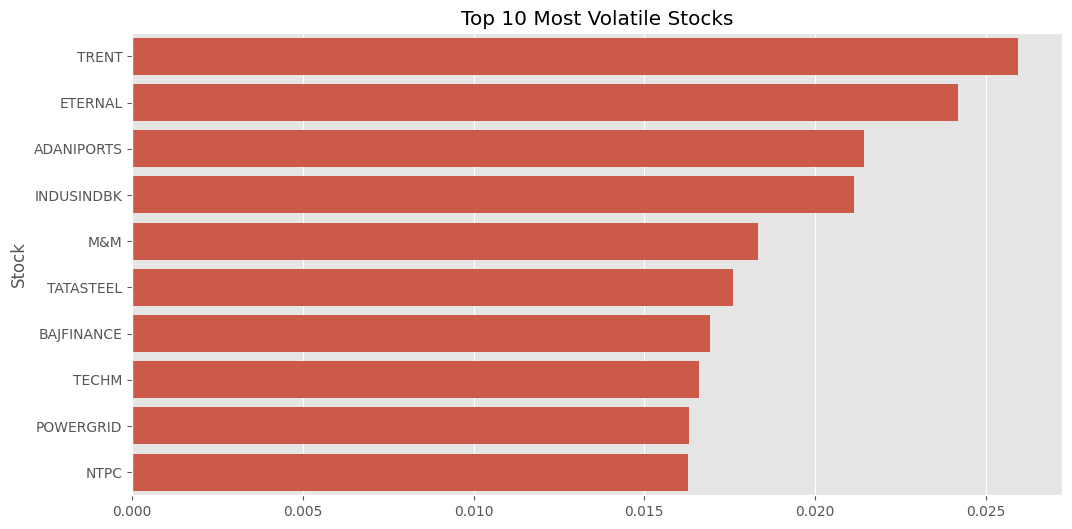

In [93]:
highest_risk = volatility.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=highest_risk.values,
    y=highest_risk.index
)

plt.title("Top 10 Most Volatile Stocks")

plt.show()

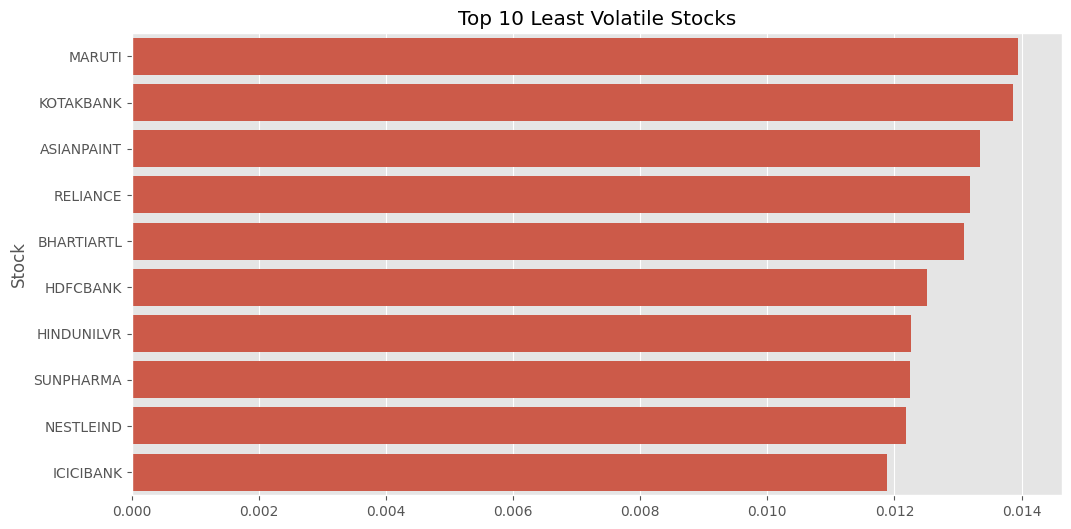

In [94]:
lowest_risk = volatility.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=lowest_risk.values,
    y=lowest_risk.index
)

plt.title("Top 10 Least Volatile Stocks")

plt.show()

In [95]:
summary = master_df.groupby("Stock").agg(
    Average_Close=("Close","mean"),
    Highest_Close=("Close","max"),
    Lowest_Close=("Close","min"),
    Average_Volume=("Volume","mean"),
    Average_Return=("Daily_Return","mean"),
    Volatility=("Daily_Return","std")
)

summary.round(2)

,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Average_Return,Volatility
Stock,,,,,,
ADANIPORTS,1287.44,1869.50,702.97,3826059.67,0.0,0.02
ASIANPAINT,2686.03,3430.49,2091.17,1201728.97,-0.0,0.01
AXISBANK,1146.46,1403.00,931.53,8324936.80,0.0,0.01
BAJAJ-AUTO,8216.03,12181.88,4373.16,434251.42,0.0,0.02
BAJFINANCE,810.25,1087.47,620.31,10406691.69,0.0,0.02
BHARTIARTL,1555.31,2162.70,843.41,6698720.10,0.0,0.01
ETERNAL,222.38,354.35,73.25,54539510.92,0.0,0.02
HCLTECH,1428.24,1872.35,986.57,3059354.56,0.0,0.02
HDFCBANK,832.12,996.42,662.64,33524660.50,0.0,0.01


In [96]:
summary.to_csv("../data/company_summary.csv")

# Key Insights

The exploratory data analysis of the historical stock prices of the Top 30 Sensex companies revealed several important observations.

## Dataset Quality

- The dataset contained no missing values or duplicate records.
- All financial values satisfied expected stock market constraints.
- Each company contained a consistent number of trading records.
- The dataset was clean and suitable for further analysis.

---

## Stock Price Behaviour

- Stock prices varied significantly across different companies.
- Price-related variables exhibited positively skewed distributions.
- High-value stocks contributed to noticeable outliers.
- Most daily price movements remained within a moderate range.

---

## Trading Volume

- Trading volume differed considerably across companies.
- Several trading sessions experienced unusually high market participation.
- Volume trends reflected changing investor activity over time.

---

## Company Performance

- Significant variation was observed in average stock prices across companies.
- Some companies consistently generated higher returns than others.
- Performance rankings clearly identified the best and worst performing stocks during the analysis period.

---

## Risk Analysis

- Daily returns were concentrated around zero with occasional extreme fluctuations.
- Volatility varied substantially across companies.
- Companies with higher volatility generally exhibited greater investment risk.
- Higher returns were not always associated with higher risk.

---

## Correlation Analysis

- Many companies exhibited strong positive correlations in their closing prices.
- Stocks belonging to similar sectors generally moved together.
- Correlation analysis highlighted diversification opportunities across sectors.

---

## Time Series Analysis

- Most companies displayed clear long-term trends in stock prices.
- Moving averages effectively smoothed daily price fluctuations.
- Rolling volatility successfully identified periods of increased market uncertainty.

---

## Overall Findings

- Historical stock performance varied significantly among companies.
- Feature engineering enhanced the analytical capabilities of the dataset.
- The generated insights provide a strong foundation for interactive financial analysis using Streamlit.

## Conclusion

This project successfully performed an Exploratory Data Analysis (EDA) on the historical stock prices of the Top 30 companies listed in the S&P BSE Sensex Index over the past three years.

The analysis included dataset exploration, data quality assessment, feature engineering, statistical analysis, company-wise comparison, correlation analysis, time series analysis, and financial performance evaluation.

Several meaningful insights were obtained regarding stock price behaviour, trading activity, investment returns, volatility, and relationships among different companies. These findings provide a comprehensive understanding of historical market performance and demonstrate the practical application of data analytics techniques in financial markets.

The engineered features and analytical results developed throughout this notebook will be utilized to build an interactive Streamlit dashboard. The dashboard will enable users to compare companies, visualize stock trends, evaluate investment risk, analyze financial performance, and explore historical market behaviour through an intuitive and user-friendly interface.

Overall, this project establishes a strong foundation for advanced financial analytics and can be further extended with predictive modeling, portfolio optimization, technical indicators, and machine learning techniques.

## Future Scope

This project can be extended further by incorporating additional financial analytics and predictive capabilities, including:

- Technical indicators such as RSI, MACD, Bollinger Bands, and Exponential Moving Averages (EMA).
- Candlestick chart visualizations for detailed price action analysis.
- Portfolio optimization using Modern Portfolio Theory (MPT).
- Stock price forecasting using machine learning and deep learning models such as Linear Regression, LSTM, or Prophet.
- Sector-wise comparative analysis and benchmark comparison with the Sensex index.
- Real-time stock data integration using financial APIs.
- Interactive filtering, stock comparison, and downloadable reports in the Streamlit dashboard.

These enhancements would transform the project from an exploratory analysis into a comprehensive financial analytics platform.